# Stage 4: RL LOD Policy Training - REINFORCE (Audit-Aligned)

Trains the Stage 4 policy on real `rollout_ep*.csv` files collected by `RLRolloutLogger`.
Exports `rl_policy_stage4.onnx` consumed by `RLPolicyController` and
`rl_scaler_constants.json` consumed by `RLFeatureExtractor`.

This notebook now applies the Stage 4 audit fixes directly:
- fails fast if native rollout files are missing or near-degenerate
- uses episode/file-group holdout instead of row-wise splitting
- matches the deployable action envelope (`[-0.20, +0.20]`) used by `RLPolicyController`
- tracks deployable action quality with dead-zone / dwell / clamp simulation diagnostics
- adds floor/ceiling dwell memory so the controller can detect when bias has been stuck near either limit

**Input**: `ml_pipeline/data/RL/Train/RLRollouts/rollout_ep*.csv`
**Output**: `ml_pipeline/models/Stage_4/rl_policy_stage4.onnx` + `rl_scaler_constants.json`

### Feature order (must match `RLFeatureExtractor.ExpectedFeatureNames` exactly)
| idx | name | notes |
|-----|------|-------|
| 0 | cpu_frame_time | ms - diagnostic only |
| 1 | gpu_frame_time | ms - reward signal source |
| 2 | fps | 1/deltaTime |
| 3 | visible_renderer_count | frustum sweep, not URP profiler |
| 4 | triangle_count | profiler recorder |
| 5 | draw_call_count | profiler recorder |
| 6 | camera_speed | m/s |
| 7 | camera_rotation_speed | deg/s |
| 8 | avg_screen_coverage | SSIM proxy |
| 9 | previous_bias | lodBias prior frame |
| 10 | recent_lod_switch_count | ring buffer count |
| 11 | floor_dwell_score | decaying accumulator near `BIAS_MIN` |
| 12 | ceiling_dwell_score | decaying accumulator near `BIAS_MAX` |

### Reward formula (matches `RLEvaluationLogger`)
```
r_t = (gpu_prev - gpu_t) + BONUS_SCALE * (gpu_t <= T_TARGET)
```


In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'sympy==1.12', 'optuna', '--quiet'])
print('Dependencies OK')

Dependencies OK


In [2]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_style('darkgrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
BASE_DIR        = Path('../..').resolve()
DATA_DIR        = BASE_DIR / 'data' / 'RL' / 'Train' / 'RLRollouts'
MODEL_DIR       = BASE_DIR / 'models' / 'Stage_4'
PLOTS_DIR       = BASE_DIR / 'plots' / 'Stage_4' / 'Train'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Reward: budget-tracking with upward bias, but less over-forced than current setup
# T_TARGET should stay data-driven above this block
BONUS_SCALE           = 1.0
REWARD_CLIP           = 5.0
GPU_VALID_MIN_MS      = 0.10
GPU_VALID_MAX_MS      = 33.3
UNDER_BUDGET_MARGIN   = 1.10
OVER_BUDGET_COEF      = 0.70
UNDER_BUDGET_COEF     = 0.60
QUALITY_REWARD_COEF   = 0.85
TARGET_ZONE_COEF      = 1.50
RECOVERY_REWARD_COEF  = 0.60
CONTROL_DIRECTION_REWARD_COEF = 0.65
NEAR_TARGET_ACTION_PENALTY_COEF = 0.08
LOW_BIAS_PENALTY_COEF = 1.40
FLOOR_MARGIN          = 0.18
CEILING_MARGIN        = 0.18
RECOVERY_BIAS_TARGET  = 1.10
RECOVERY_BIAS_TOL     = 0.10
SAFE_RECOVERY_GPU_MARGIN = 0.25
FLOOR_RECOVERY_MIN_STRENGTH = 1.00
CEILING_CORRECTION_MIN_STRENGTH = 0.22
NEAR_TARGET_FLOOR_RECOVERY_SCALE = 1.35
NEAR_TARGET_CEILING_CORRECTION_SCALE = 0.25
TARGET_PROX_SIGMA     = 1.75

# Runtime guardrails (must match Unity deployment)
DEAD_ZONE        = 0.02
DWELL_FRAMES     = 5
BIAS_MIN         = 0.30
BIAS_MAX         = 2.00
DWELL_ACCUMULATION_RATE = 0.30
DWELL_DECAY            = 0.92
DWELL_ACTIVE_THRESHOLD = 0.28
FLOOR_DWELL_RECOVERY_GAIN = 1.35
CEILING_DWELL_CORRECTION_GAIN = 0.40
RECOVERY_ELIGIBLE_BIAS = 1.05
CORRECTION_ELIGIBLE_BIAS = 1.60
RECOVERY_GROWTH_THRESHOLD = 0.035
RECOVERY_TRIGGER_FRAMES = 2
RECOVERY_FORCE_MULTIPLIER = 2.50
RECOVERY_FORCE_MAX = 9.0
RECOVERY_BOOST_BASE = 0.12
RECOVERY_BUDGET_RESET_MARGIN = 0.25

# Legacy weights (not used in reward; retained for report parity)
ALPHA            = 1.0
BETA             = 0.5
GAMMA_W          = 0.0
N_MAX            = 30.0

# REINFORCE / rollout-policy training hyperparameters
GAMMA_RL           = 0.99
TRAIN_SIGMA        = 0.10
ACTION_HEAD_SCALE  = 0.30
PG_COEF            = 1.50
BC_COEF_START      = 0.10
BC_COEF_END        = 0.01
ZERO_BC_WEIGHT     = 0.08
NONZERO_BC_WEIGHT  = 1.0
SUPPORT_MARGIN     = 0.015
SUPPORT_COEF_START = 0.10
SUPPORT_COEF_END   = 0.00
SAT_WARN_THRESHOLD = ACTION_HEAD_SCALE - 0.01
SAT_COEF              = 1.0
NEG_SAT_COEF          = 6.0
FLOOR_COEF            = 1.5
HEADROOM_PUSH_COEF    = 3.0
OVER_BUDGET_POS_COEF  = 8.0
NEAR_TARGET_ZERO_COEF = 0.25
NEAR_TARGET_NEG_COEF  = 2.0
LOW_BIAS_RECOVERY_COEF = 15.0
HIGH_BIAS_TRIM_COEF    = 2.0
CONTROL_COEF          = 2.0
CONTROL_OVER_WEIGHT   = 1.8
CONTROL_UNDER_WEIGHT  = 2.6
CONTROL_NEAR_WEIGHT   = 1.5
CONTROL_FLOOR_BOOST   = 4.0
CONTROL_DEADBAND_MS   = 0.25
CONTROL_RESPONSE_MS   = 2.25
CONTROL_TARGET_TOL    = 0.010
ENTROPY_COEF          = 0.010
DEAD_ZONE_COEF        = 3.0  # Penalize "ghost" actions in dead zone range [0, 0.02)
POS_SAT_COEF          = 2.5
DEPLOY_ACTIVE_TARGET  = 3.0
VAL_GROUP_FRAC        = 0.20
GRAD_CLIP             = 1.0
BATCH_SIZE            = 256
RANDOM_SEED           = 42



torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

FEATURE_COUNT = 13
FEATURE_COLS  = [
    'cpu_frame_time',
    'gpu_frame_time',
    'fps',
    'visible_renderer_count',
    'triangle_count',
    'draw_call_count',
    'camera_speed',
    'camera_rotation_speed',
    'avg_screen_coverage',
    'previous_bias',
    'recent_lod_switch_count',
    'floor_dwell_score',
    'ceiling_dwell_score'
]

print(f'Device:              {device}')
print(f'DATA_DIR:            {DATA_DIR}')
print(f'TRAIN_SIGMA:         {TRAIN_SIGMA:.3f}')
print(f'ACTION_HEAD_SCALE:   {ACTION_HEAD_SCALE:.3f}')
print(f'PG_COEF:             {PG_COEF:.2f}')
print(f'BC_COEF schedule:    {BC_COEF_START:.2f} -> {BC_COEF_END:.2f}')
print(f'SUPPORT_COEF sched:  {SUPPORT_COEF_START:.2f} -> {SUPPORT_COEF_END:.2f}')
print(f'ENTROPY_COEF:        {ENTROPY_COEF:.4f}')
print(f'SAT_WARN_THRESHOLD:  {SAT_WARN_THRESHOLD:.3f}')
print(f'Budget margins:      under={UNDER_BUDGET_MARGIN:.2f} floor_margin={FLOOR_MARGIN:.2f} ceiling_margin={CEILING_MARGIN:.2f}')
print(f'Reward shaping:      over={OVER_BUDGET_COEF:.2f} under={UNDER_BUDGET_COEF:.2f} quality={QUALITY_REWARD_COEF:.2f} recovery={RECOVERY_REWARD_COEF:.2f} dir={CONTROL_DIRECTION_REWARD_COEF:.2f} sigma={TARGET_PROX_SIGMA:.2f}')
print(f'Collapse penalties:  neg_sat={NEG_SAT_COEF:.2f} floor={FLOOR_COEF:.2f} headroom_push={HEADROOM_PUSH_COEF:.2f} over_budget_pos={OVER_BUDGET_POS_COEF:.2f}')
print(f'Control target:      coef={CONTROL_COEF:.2f} deadband={CONTROL_DEADBAND_MS:.2f}ms response={CONTROL_RESPONSE_MS:.2f}ms tol={CONTROL_TARGET_TOL:.3f} zero_bc={ZERO_BC_WEIGHT:.2f} weights(o/u/n)={CONTROL_OVER_WEIGHT:.1f}/{CONTROL_UNDER_WEIGHT:.1f}/{CONTROL_NEAR_WEIGHT:.1f}')
print(f'Dwell memory:        accum={DWELL_ACCUMULATION_RATE:.2f} decay={DWELL_DECAY:.2f} active>={DWELL_ACTIVE_THRESHOLD:.2f} floor_gain={FLOOR_DWELL_RECOVERY_GAIN:.2f} ceiling_gain={CEILING_DWELL_CORRECTION_GAIN:.2f}')
print(f'Recovery assist:     floor<={RECOVERY_ELIGIBLE_BIAS:.2f} ceiling>={CORRECTION_ELIGIBLE_BIAS:.2f} weak<{RECOVERY_GROWTH_THRESHOLD:.2f} trigger={RECOVERY_TRIGGER_FRAMES}x mult={RECOVERY_FORCE_MULTIPLIER:.2f} max={RECOVERY_FORCE_MAX:.2f}')
print(f'Runtime guardrails:  dead_zone={DEAD_ZONE:.2f} dwell={DWELL_FRAMES} bias=[{BIAS_MIN:.2f}, {BIAS_MAX:.2f}]')
print(f'GPU valid ms:        [{GPU_VALID_MIN_MS:.2f}, {GPU_VALID_MAX_MS:.1f}]')


Device:              cuda
DATA_DIR:            C:\Users\Gica\neural-lod\ml_pipeline\data\RL\Train\RLRollouts
TRAIN_SIGMA:         0.100
ACTION_HEAD_SCALE:   0.300
PG_COEF:             1.50
BC_COEF schedule:    0.10 -> 0.01
SUPPORT_COEF sched:  0.10 -> 0.00
ENTROPY_COEF:        0.0100
SAT_WARN_THRESHOLD:  0.290
Budget margins:      under=1.10 floor_margin=0.18 ceiling_margin=0.18
Reward shaping:      over=0.70 under=0.60 quality=0.85 recovery=0.60 dir=0.65 sigma=1.75
Collapse penalties:  neg_sat=6.00 floor=1.50 headroom_push=3.00 over_budget_pos=8.00
Control target:      coef=2.00 deadband=0.25ms response=2.25ms tol=0.010 zero_bc=0.08 weights(o/u/n)=1.8/2.6/1.5
Dwell memory:        accum=0.30 decay=0.92 active>=0.28 floor_gain=1.35 ceiling_gain=0.40
Recovery assist:     floor<=1.05 ceiling>=1.60 weak<0.04 trigger=2x mult=2.50 max=9.00
Runtime guardrails:  dead_zone=0.02 dwell=5 bias=[0.30, 2.00]
GPU valid ms:        [0.10, 33.3]


## 1. Load Rollout CSVs
Reads `rollout_ep*.csv` files produced by `RLRolloutLogger`.
Audit guardrail: Stage 4 training now fails fast if native rollout files are missing.


In [4]:
REQUIRED_ROLLOUT_COLUMNS = {
    'episode',
    'step',
    'cpu_frame_time',
    'gpu_frame_time',
    'fps',
    'visible_renderer_count',
    'triangle_count',
    'draw_call_count',
    'camera_speed',
    'camera_rotation_speed',
    'avg_screen_coverage',
    'previous_bias',
    'recent_lod_switch_count',
    'lod_bias_before_action',
    'action_delta',
    'lod_bias_after_action'
}

rollout_files = sorted(DATA_DIR.glob('rollout_ep*.csv'))
print(f'rollout_ep*.csv: {len(rollout_files)}')

if not rollout_files:
    raise FileNotFoundError('Stage 4 training now requires native rollout_ep*.csv files.'        'Audit findings block training_data_*.csv / inference_eval_*.csv fallbacks.'  f'Expected files under: {DATA_DIR}')

dfs = []
for f in rollout_files:
    df = pd.read_csv(f)
    missing = sorted(REQUIRED_ROLLOUT_COLUMNS.difference(df.columns))
    if missing:
        raise ValueError(f'{f.name} is missing required rollout columns: {missing}')
    df['source_file'] = f.name
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)

numeric_cols = [
    'episode', 'step', 'cpu_frame_time', 'gpu_frame_time', 'fps',
    'visible_renderer_count', 'triangle_count', 'draw_call_count',
    'camera_speed', 'camera_rotation_speed', 'avg_screen_coverage',
    'previous_bias', 'recent_lod_switch_count',
    'lod_bias_before_action', 'action_delta', 'lod_bias_after_action'
]
for col in numeric_cols:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

print(f'Raw rows   : {len(raw):,}')
print(f'Episodes   : {raw["episode"].nunique()}')
print(f'Files      : {raw["source_file"].nunique()}')
print(f'Steps / ep : {raw.groupby("episode").size().mean():.0f}')

if raw['source_file'].nunique() < 2 and raw['episode'].nunique() < 2:
    raise ValueError(
        'Need at least 2 rollout files or 2 episodes for an audit-safe holdout split. '
        f'Found files={raw["source_file"].nunique()} episodes={raw["episode"].nunique()}.'
    )

print('Rows per rollout file:')
display(raw.groupby('source_file').size().sort_values().to_frame('rows'))
raw.head(3)


rollout_ep*.csv: 9
Raw rows   : 6,701
Episodes   : 3
Files      : 9
Steps / ep : 2234
Rows per rollout file:


,rows
source_file,
rollout_ep0001_20260406_202521.csv,57
rollout_ep0001_20260406_202726.csv,240
rollout_ep0002_20260406_202112.csv,353
rollout_ep0001_20260406_202238.csv,931
rollout_ep0000_20260406_202546.csv,1024
rollout_ep0000_20260406_202341.csv,1024
rollout_ep0000_20260406_202148.csv,1024
rollout_ep0000_20260406_201930.csv,1024
rollout_ep0001_20260406_202023.csv,1024


,episode,step,cpu_frame_time,gpu_frame_time,fps,visible_renderer_count,triangle_count,draw_call_count,camera_speed,camera_rotation_speed,avg_screen_coverage,previous_bias,recent_lod_switch_count,floor_dwell_score,ceiling_dwell_score,lod_bias_before_action,action_delta,lod_bias_after_action,source_file
0,0,0,17.5170,0.4669,50.00,21323,379233,2562,0.0,0.0,0.002375,2.00,1,0.0,0.3000,1.0,0.00,1.00,rollout_ep0000_20260406_201930.csv
1,0,1,32.4352,27.6275,32.73,21323,561799,5115,0.0,0.0,0.002375,1.00,2,0.0,0.1819,1.0,-0.05,0.95,rollout_ep0000_20260406_201930.csv
2,0,2,35.3487,25.9103,18.69,21323,141559,1505,0.0,0.0,0.002375,0.95,2,0.0,0.1540,1.0,0.00,0.95,rollout_ep0000_20260406_201930.csv


make sure the data loaded is compatible

In [5]:
# AFTER concatenating dfs into raw

raw = pd.concat(dfs, ignore_index=True)

# =========================
# FIX: REBUILD EPISODES
# =========================
if raw['episode'].isna().all():
    print("Fixing missing episode column...")

    # create episode from step reset
    raw['episode'] = (raw['step'] == 0).cumsum()

    # fallback if no reset exists
    if raw['episode'].nunique() == 1:
        print("No step reset detected â†’ single episode fallback")
        raw['episode'] = 0

print("Episodes after fix:", raw['episode'].nunique())

Episodes after fix: 3


## 2. Data Cleaning
Remove corrupt or warmup frames using the same GPU validity window implied by the Stage 4 docs and scripts.
Bootstrap rollouts are expected to be quantized because `RLPolicyController` applies a dead zone and dwell guard before logging `action_delta`.

In [6]:
# Remove invalid / corrupt timing rows
# Audit guardrail: fail fast on degenerate training features instead of training through them.
df_clean = raw[
    (raw['cpu_frame_time'] > 0) &
    (raw['gpu_frame_time'] >= GPU_VALID_MIN_MS) &
    (raw['gpu_frame_time'] <= GPU_VALID_MAX_MS)
].copy()

print(f'After timing filter: {len(df_clean):,} rows ({100 * len(df_clean) / len(raw):.1f}% kept)')

if len(df_clean) == 0:
    raise ValueError('All rows removed by timing filter -- check rollout collection')

base_feature_cols = [
    'cpu_frame_time', 'gpu_frame_time', 'fps', 'visible_renderer_count', 'triangle_count',
    'draw_call_count', 'camera_speed', 'camera_rotation_speed', 'avg_screen_coverage',
    'previous_bias', 'recent_lod_switch_count'
]
df_clean = df_clean.dropna(subset=base_feature_cols + ['action_delta']).copy()
print(f'After NaN drop:      {len(df_clean):,} rows')

if len(df_clean) == 0:
    raise ValueError('All rows removed after NaN drop')

sequence_group_col = 'source_file' if 'source_file' in df_clean.columns else 'episode'
df_clean = df_clean.sort_values([sequence_group_col, 'step']).reset_index(drop=True)


def add_bias_dwell_features(df, group_col):
    floor_scores = np.zeros(len(df), dtype=np.float32)
    ceiling_scores = np.zeros(len(df), dtype=np.float32)

    for _, grp in df.groupby(group_col, sort=False):
        floor_score = 0.0
        ceiling_score = 0.0
        idx = grp.index.to_numpy()
        bias_values = grp['previous_bias'].to_numpy(dtype=np.float32)

        for pos, bias in zip(idx, bias_values):
            floor_proximity = np.clip(((BIAS_MIN + FLOOR_MARGIN) - bias) / max(FLOOR_MARGIN, 1e-6), 0.0, 1.0)
            ceiling_proximity = np.clip((bias - (BIAS_MAX - CEILING_MARGIN)) / max(CEILING_MARGIN, 1e-6), 0.0, 1.0)
            floor_score = np.clip(floor_score * DWELL_DECAY + floor_proximity * DWELL_ACCUMULATION_RATE, 0.0, 1.0)
            ceiling_score = np.clip(ceiling_score * DWELL_DECAY + ceiling_proximity * DWELL_ACCUMULATION_RATE, 0.0, 1.0)
            floor_scores[pos] = floor_score
            ceiling_scores[pos] = ceiling_score

    out = df.copy()
    out['floor_dwell_score'] = floor_scores
    out['ceiling_dwell_score'] = ceiling_scores
    return out


df_clean = add_bias_dwell_features(df_clean, sequence_group_col)

a = pd.to_numeric(df_clean['action_delta'], errors='coerce').fillna(0).astype('float32')
action_counts = a.value_counts().sort_index()

print('Observed rollout action distribution:')
print(action_counts.to_string())
print(f'Non-zero action % : {(a.abs() > 1e-6).mean() * 100:.1f}')
print(f'Near-zero action %: {(a.abs() < 0.005).mean() * 100:.1f}')

feature_nonzero = (df_clean[FEATURE_COLS] != 0).mean() * 100
print('Feature non-zero % after timing filter:')
print(feature_nonzero.to_string())

bad_features = feature_nonzero[feature_nonzero < 1.0]
if len(bad_features):
    lines = [f'  {name}: {pct:.2f}% non-zero' for name, pct in bad_features.items()]
    raise ValueError(
        'Audit guardrail tripped: near-all-zero Stage 4 features remain after cleaning:\n' +
        '\n'.join(lines)
    )
print('Dwell feature summary:')
print(df_clean[['floor_dwell_score', 'ceiling_dwell_score']].describe().round(4).to_string())

ep_stats = df_clean.groupby('episode').agg(
    steps=('step', 'count'),
    mean_gpu=('gpu_frame_time', 'mean'),
    mean_fps=('fps', 'mean'),
    mean_bias=('lod_bias_after_action', 'mean'),
    mean_floor_dwell=('floor_dwell_score', 'mean'),
    mean_ceiling_dwell=('ceiling_dwell_score', 'mean')
).round(3)
print(f'Episode summary ({len(ep_stats)} episodes):')
display(ep_stats.head(10))


After timing filter: 6,701 rows (100.0% kept)
After NaN drop:      6,701 rows
Observed rollout action distribution:
action_delta
-0.0992       1
-0.0864       1
-0.0800      13
-0.0770       5
-0.0664      13
-0.0500     384
-0.0492      55
-0.0484       1
-0.0390       1
-0.0380       1
-0.0365     219
-0.0270     374
 0.0000    4723
 0.0269       2
 0.0270       6
 0.0300       1
 0.0420       1
 0.0428       1
 0.0444       1
 0.0500     893
 0.0770       5
Non-zero action % : 29.5
Near-zero action %: 70.5
Feature non-zero % after timing filter:
cpu_frame_time             100.000000
gpu_frame_time             100.000000
fps                        100.000000
visible_renderer_count     100.000000
triangle_count             100.000000
draw_call_count            100.000000
camera_speed                44.963438
camera_rotation_speed       55.364871
avg_screen_coverage        100.000000
previous_bias              100.000000
recent_lod_switch_count     82.256380
floor_dwell_score          

,steps,mean_gpu,mean_fps,mean_bias,mean_floor_dwell,mean_ceiling_dwell
episode,,,,,,
0,4096,7.527,47.889,1.228,0.219,0.074
1,2252,5.494,77.431,0.808,0.349,0.014
2,353,5.137,74.196,1.328,0.000,0.203


Assign a GPU Target based on data to avoid unrealistic gpu targets that cannot possibly be learns from the avaiable data 

In [7]:
gpu_series = df_clean['gpu_frame_time'].dropna().astype('float32')

if gpu_series.empty:
    raise ValueError('gpu_frame_time has no valid rows')

p25 = gpu_series.quantile(0.25)
p40 = gpu_series.quantile(0.40)

T_TARGET = float(0.5 * (p25 + p40))  # midpoint

print(f'T_TARGET (dynamic) = {T_TARGET:.3f} ms')
print(f'GPU stats | mean={gpu_series.mean():.3f} '
      f'median={gpu_series.median():.3f} '
      f'p25={p25:.3f} p40={p40:.3f} p75={gpu_series.quantile(0.75):.3f}')

T_TARGET (dynamic) = 5.418 ms
GPU stats | mean=6.718 median=6.224 p25=5.130 p40=5.706 p75=7.584


## 3. Feature Scaling
Fit `StandardScaler` on the 13-feature state vector and save `rl_scaler_constants.json`.  
Copy this JSON to `Assets/StreamingAssets/` for `RLFeatureExtractor` to load at runtime.


Scaling OK: (6701, 13)
Saved: C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_scaler_constants.json


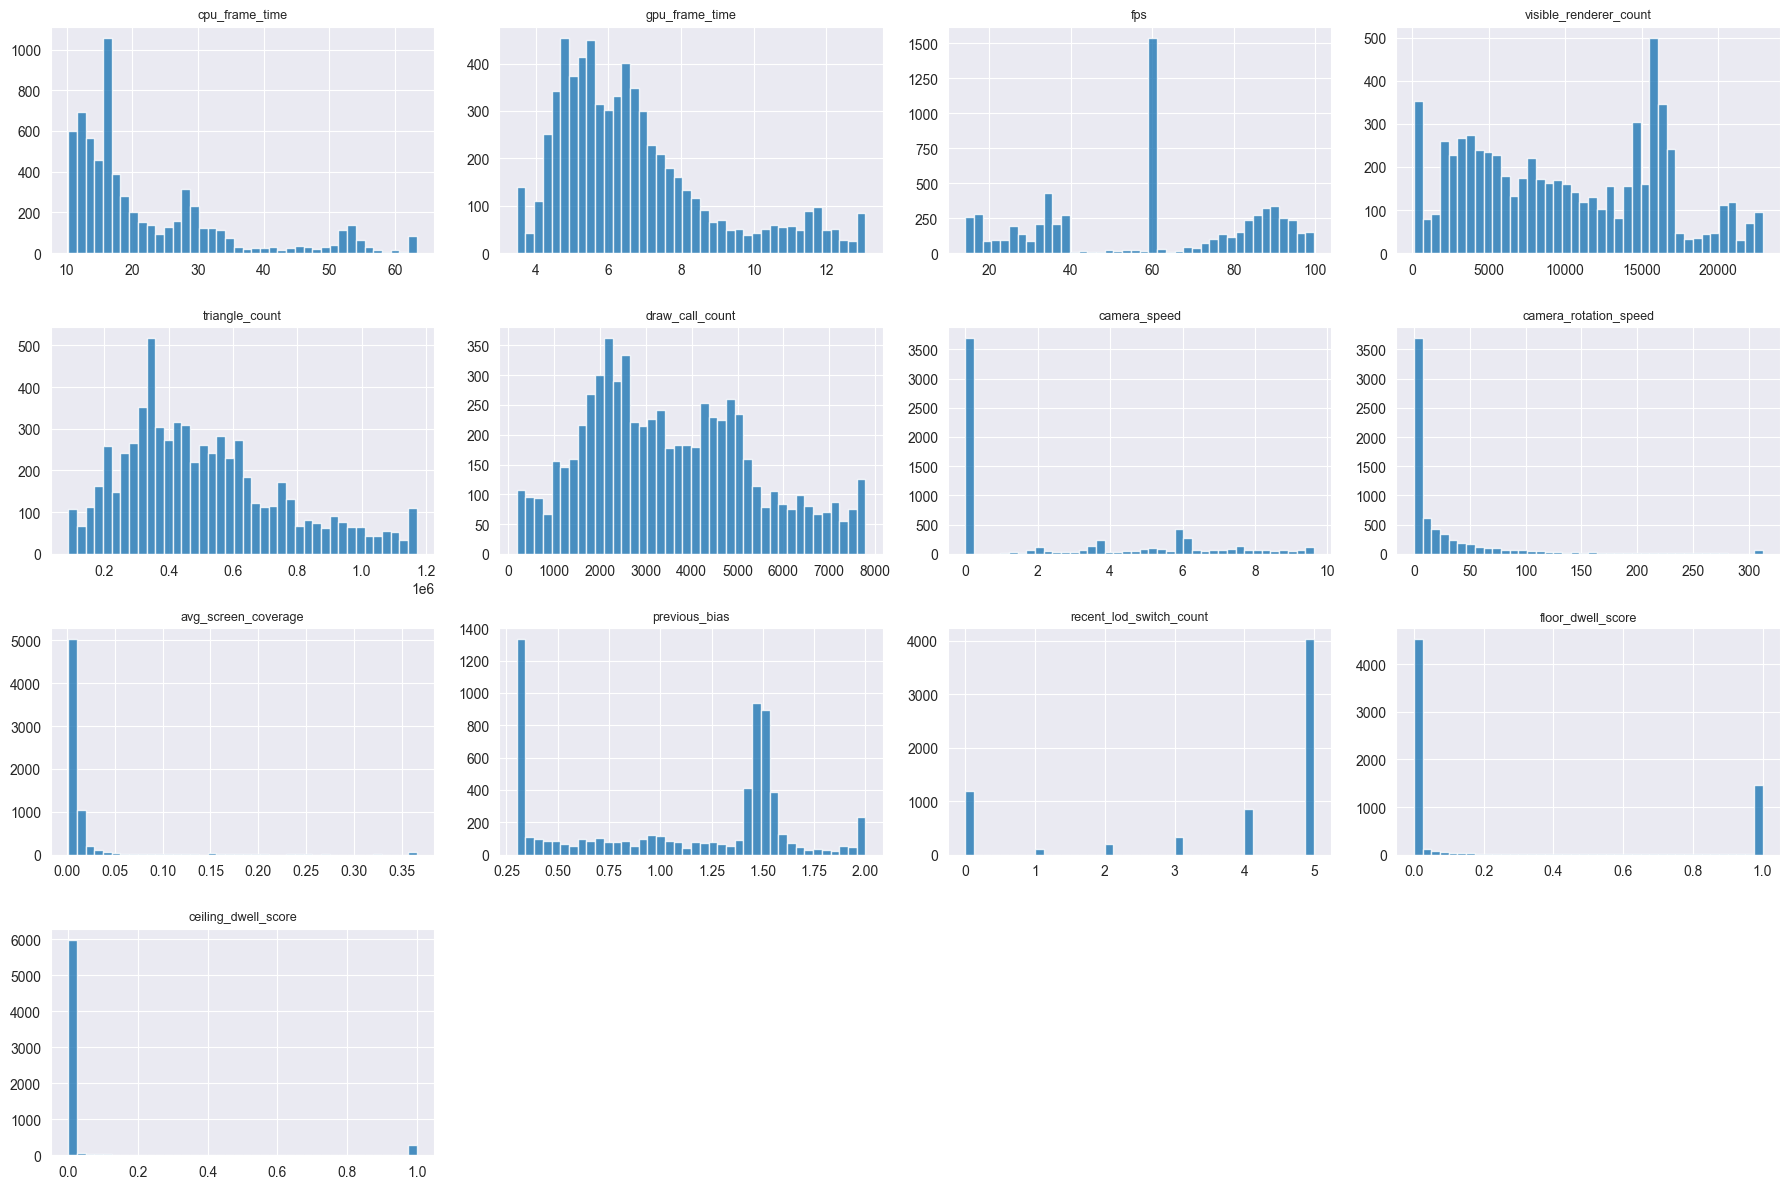

Final rows: 6701
Episodes  : 3


In [8]:
# Build scaler from cleaned native Stage 4 rollouts only.
X_raw = df_clean[FEATURE_COLS].values.astype(np.float32)

if X_raw.shape[0] == 0:
    raise ValueError('No samples available for scaling')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

zero_scale = [
    (name, float(scale))
    for name, scale in zip(FEATURE_COLS, scaler.scale_)
    if scale < 1e-8
]
if zero_scale:
    raise ValueError(f'Zero-scale features detected: {zero_scale}')

scaler_data = {
    'feature_names': FEATURE_COLS,
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist(),
    't_target_ms': float(T_TARGET),
    # Training hyperparameters
    'action_head_scale': ACTION_HEAD_SCALE,
    'max_action_delta': ACTION_HEAD_SCALE,  # Must match Unity maxActionDelta
    'dead_zone': 0.02,
    'dwell_frames': 5,
    'bias_min': 0.30,
    'bias_max': 2.00,
    'inference_interval': 2,
    # Training configuration (for audit/reference)
    'pg_coef': float(PG_COEF),
    'bc_coef_start': BC_COEF_START,
    'bc_coef_end': BC_COEF_END,
    # Loss function hyperparameters (exported for C# debugging and validation)
    'gpu_target_ms_base': T_TARGET,
    'gpu_target_ms_min': 4.0,
    'gpu_target_ms_max': 6.5,
    'scene_complexity_scale': 0.8,
    'scene_complexity_normalization': 50.0,
    'mode_headroom_margin_ms': 0.5,
    'mode_headroom_fps_floor': 48,
    'mode_budget_fps_floor': 45,
    'exploration_upward_weight': 0.4,
    'recovery_downward_weight': 0.6,
    'thrash_penalty_weight': 0.1,
    'nominal_action_regularization': 0.08,
    'exploration_action_regularization': 0.05,
    'recovery_action_regularization': 0.1,
}

scaler_path = MODEL_DIR / 'rl_scaler_constants.json'
with open(scaler_path, 'w', encoding='utf-8') as f:
    json.dump(scaler_data, f, indent=2)

print('Scaling OK:', X_scaled.shape)
print('Saved:', scaler_path)

fig, axes = plt.subplots(4, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    col_data = df_clean[col]
    clipped = col_data.clip(
        lower=col_data.quantile(0.01),
        upper=col_data.quantile(0.99)
    )
    axes[i].hist(clipped, bins=40, alpha=0.8)
    axes[i].set_title(col, fontsize=9)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_distributions.png', dpi=150)
plt.show()

print('Final rows:', len(df_clean))
print('Episodes  :', df_clean['episode'].nunique())

In [9]:
print("\n=== DATA DISTRIBUTION ANALYSIS ===")

for source_file in df_clean['source_file'].unique():
    subset = df_clean[df_clean['source_file'] == source_file]
    gpu = subset['gpu_frame_time']

    gpu_mean = gpu.mean()
    over_budget = (gpu > T_TARGET).mean() * 100
    under_budget = (gpu <= T_TARGET).mean() * 100

    print(f"\n{source_file}:")
    print(f"  Frames: {len(subset):,}")
    print(f"  GPU mean: {gpu_mean:.2f} ms")
    print(f"  Over-budget (>{T_TARGET:.3f}ms): {over_budget:.1f}%")
    print(f"  Under-budget (<={T_TARGET:.3f}ms): {under_budget:.1f}%")

print(f"\nTotal frames: {len(df_clean):,}")

overall_over = (df_clean['gpu_frame_time'] > T_TARGET).mean() * 100
overall_under = (df_clean['gpu_frame_time'] <= T_TARGET).mean() * 100

print(f"Overall over-budget (>{T_TARGET:.3f}ms): {overall_over:.1f}%")
print(f"Overall under-budget (<={T_TARGET:.3f}ms): {overall_under:.1f}%")


=== DATA DISTRIBUTION ANALYSIS ===

rollout_ep0000_20260406_201930.csv:
  Frames: 1,024
  GPU mean: 6.25 ms
  Over-budget (>5.418ms): 74.7%
  Under-budget (<=5.418ms): 25.3%

rollout_ep0000_20260406_202148.csv:
  Frames: 1,024
  GPU mean: 6.41 ms
  Over-budget (>5.418ms): 83.4%
  Under-budget (<=5.418ms): 16.6%

rollout_ep0000_20260406_202341.csv:
  Frames: 1,024
  GPU mean: 9.01 ms
  Over-budget (>5.418ms): 96.1%
  Under-budget (<=5.418ms): 3.9%

rollout_ep0000_20260406_202546.csv:
  Frames: 1,024
  GPU mean: 8.45 ms
  Over-budget (>5.418ms): 85.6%
  Under-budget (<=5.418ms): 14.4%

rollout_ep0001_20260406_202023.csv:
  Frames: 1,024
  GPU mean: 5.26 ms
  Over-budget (>5.418ms): 42.5%
  Under-budget (<=5.418ms): 57.5%

rollout_ep0001_20260406_202238.csv:
  Frames: 931
  GPU mean: 5.22 ms
  Over-budget (>5.418ms): 31.5%
  Under-budget (<=5.418ms): 68.5%

rollout_ep0001_20260406_202521.csv:
  Frames: 57
  GPU mean: 8.13 ms
  Over-budget (>5.418ms): 100.0%
  Under-budget (<=5.418ms): 0.

## 4. Reward Computation

**Budget-tracking reward with quality preservation**:
```
r_t = budget_tracking(gpu_t, T_TARGET)
    + under_budget_quality_bonus(avg_screen_coverage, lod_bias_after_action)
    + recovery_bonus(max(lod_bias_after_action - lod_bias_before_action, 0))
    - low_bias_penalty(if gpu_t is already comfortably under target)
```
This keeps the Stage 4 objective focused on the real goal: meet the GPU budget with the minimum necessary quality loss, not just push quality downward forever.


In [10]:
# BUDGET-TRACKING REWARD WITH QUALITY PRESERVATION
#
# The audit-aligned objective should prefer the highest-quality state that still
# respects the GPU budget. Pure improvement rewards made the policy collapse
# toward the minimum allowed LOD bias.

df_clean = df_clean.sort_values(['episode', 'step']).reset_index(drop=True)

gpu = df_clean['gpu_frame_time'].values.astype('float32')
coverage = df_clean['avg_screen_coverage'].values.astype('float32')
bias_before = df_clean['lod_bias_before_action'].values.astype('float32')
bias_after = df_clean['lod_bias_after_action'].values.astype('float32')

coverage_q95 = float(np.quantile(coverage, 0.95)) if len(coverage) else 1.0
coverage_scale = max(coverage_q95, 1e-4)
coverage_norm = np.clip(coverage / coverage_scale, 0.0, 1.0).astype('float32')
bias_norm = np.clip((bias_after - BIAS_MIN) / max(BIAS_MAX - BIAS_MIN, 1e-6), 0.0, 1.0).astype('float32')

over_budget = np.clip(gpu - T_TARGET, 0.0, None).astype('float32')
under_budget = np.clip(T_TARGET - gpu, 0.0, None).astype('float32')
under_budget_headroom = (under_budget >= UNDER_BUDGET_MARGIN).astype('float32')
near_target = ((np.abs(gpu - T_TARGET) <= CONTROL_DEADBAND_MS)).astype('float32')
signed_bias_delta = (bias_after - bias_before).astype('float32')

target_proximity = np.exp(-((gpu - T_TARGET) ** 2) / (2.0 * TARGET_PROX_SIGMA ** 2)).astype('float32')
r_budget = (
    BONUS_SCALE * target_proximity
    - OVER_BUDGET_COEF * over_budget
    - UNDER_BUDGET_COEF * under_budget
)
r_recovery = RECOVERY_REWARD_COEF * under_budget_headroom * np.clip(bias_after - bias_before, 0.0, None).astype('float32')

rewards = np.clip(r_budget + r_recovery, -REWARD_CLIP, REWARD_CLIP).astype('float32')

if len(rewards) == 0:
    raise ValueError('rewards is empty -- df_clean is empty')

pos_pct = float((rewards > 0).mean() * 100)
print(f'Reward | mean={rewards.mean():.4f} std={rewards.std():.4f} min={rewards.min():.4f} max={rewards.max():.4f}')
print(f'Positive steps: {(rewards > 0).sum():,}/{len(rewards):,} ({pos_pct:.1f}%)')
print(f'Coverage scale (q95): {coverage_scale:.5f}')
print(f'Under-budget headroom steps: {under_budget_headroom.sum():,.0f}/{len(rewards):,}')

if pos_pct < 1.0:
    raise ValueError(
        f'Only {pos_pct:.1f}% positive rewards -- check GPU data quality.\n'
        'Ensure training_data_*.csv has valid per-frame gpu_frame_time_ms values.'
    )

df_clean = df_clean.copy()
df_clean['reward'] = rewards


Reward | mean=-0.5133 std=1.5977 min=-5.0000 max=1.0000
Positive steps: 3,653/6,701 (54.5%)
Coverage scale (q95): 0.03809
Under-budget headroom steps: 396/6,701


## 5. Policy Network
Deterministic deployment policy MLP.
- **Input**: 11 normalized state features
- **Output**: action mean `mu` (scalar) bounded to the bootstrap support band `[-0.06, +0.06]` for fallback-policy training
- **Training log-prob sigma**: fixed constant `TRAIN_SIGMA` used only inside the REINFORCE loss
- ONNX exports only `mu` â€” Unity `RLPolicyController` reads `output[0]` deterministically


In [11]:
class PolicyMLP(nn.Module):
    def __init__(self, in_dim, h1, h2, h3, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, h3),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h3, 1),  # single output: mu
        )
        # Learnable log_sigma (scalar per mini‑batch; shared across batch)
        self.log_sigma = nn.Parameter(torch.tensor(-0.5))

    def forward(self, x):
        mu = self.net(x)              # shape [B, 1]
        log_sigma = self.log_sigma    # scalar (will broadcast)
        mu = 0.3 * ACTION_HEAD_SCALE * torch.tanh(mu)
        sigma = torch.exp(self.log_sigma).clamp(0.1, 1.0)
        if self.training:
            mu = mu + torch.randn_like(mu) * sigma * 0.05
        return mu.squeeze(-1), log_sigma  # squeezes to [B], keeps log_sigma scalar

## 6. Hyperparameter Tuning (Optuna)


### Returns and Train/Val Split
Discounted returns `G_t` computed per episode, then normalized globally.


In [12]:
# REINFORCE Returns

if len(df_clean) == 0:
    raise ValueError('df_clean is empty')
if 'reward' not in df_clean.columns:
    raise ValueError("'reward' column missing -- run Reward Computation cell first")

pos_pct = float((df_clean['reward'] > 0).mean() * 100)
if pos_pct < 1.0:
    raise ValueError(f'Only {pos_pct:.1f}% positive rewards -- check reward cell')

def compute_returns(rewards_ep, gamma):
    G = np.zeros_like(rewards_ep, dtype='float32')
    running = 0.0
    for t in reversed(range(len(rewards_ep))):
        running = float(rewards_ep[t]) + gamma * running
        G[t] = running
    return G

df_clean = df_clean.sort_values(['episode', 'step']).reset_index(drop=True)
returns_list = []
for _, grp in df_clean.groupby('episode', sort=False):
    returns_list.append(compute_returns(grp['reward'].values, GAMMA_RL))

df_clean['G_t'] = np.concatenate(returns_list)
G_mean = df_clean['G_t'].mean()
G_std  = df_clean['G_t'].std() + 1e-8
df_clean['G_t_norm'] = (df_clean['G_t'] - G_mean) / G_std

print(f'Returns shape: {df_clean["G_t_norm"].shape}')
print(f'G_t   | mean={df_clean["G_t"].mean():.4f} std={df_clean["G_t"].std():.4f}')
print(f'G_norm| mean={df_clean["G_t_norm"].mean():.4f} std={df_clean["G_t_norm"].std():.4f}')


Returns shape: (6701,)
G_t   | mean=-49.1350 std=84.5344
G_norm| mean=-0.0000 std=1.0000


Quick trials to find the best architecture and learning rate for the deployable `mu` policy.
The objective combines REINFORCE validation loss with action-fit and saturation penalties,
which is more faithful to the Stage 4 runtime than tuning raw loss alone.

In [13]:
from sklearn.model_selection import GroupShuffleSplit
import logging
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s'
)
X_all = X_scaled
A_all = df_clean['action_delta'].values.astype('float32')
G_all = df_clean['G_t_norm'].values.astype('float32')
group_col = 'source_file' if 'source_file' in df_clean.columns and df_clean['source_file'].nunique() >= 2 else 'episode'
groups = df_clean[group_col].astype(str).values
unique_groups = pd.Index(pd.Series(groups).unique())
if len(unique_groups) < 2:
    raise ValueError(f'Need at least 2 unique {group_col} groups for a holdout split; found {len(unique_groups)}.')
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=VAL_GROUP_FRAC,
    random_state=RANDOM_SEED
)
train_idx, val_idx = next(splitter.split(X_all, A_all, groups=groups))
X_tr, X_val = X_all[train_idx], X_all[val_idx]
A_tr, A_val = A_all[train_idx], A_all[val_idx]
G_tr, G_val = G_all[train_idx], G_all[val_idx]
df_train = df_clean.iloc[train_idx].copy()
df_val = df_clean.iloc[val_idx].copy()
print(f'Holdout split uses: {group_col}')
print(f'Train groups      : {df_train[group_col].nunique()}')
print(f'Val groups        : {df_val[group_col].nunique()}')
print(f'Train rows        : {len(df_train):,}')
print(f'Val rows          : {len(df_val):,}')
X_tr_t  = torch.tensor(X_tr, dtype=torch.float32, device=device)
A_tr_t  = torch.tensor(A_tr, dtype=torch.float32, device=device)
G_tr_t  = torch.tensor(G_tr, dtype=torch.float32, device=device)
X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)
A_val_t = torch.tensor(A_val, dtype=torch.float32, device=device)
G_val_t = torch.tensor(G_val, dtype=torch.float32, device=device)
ACTION_SUPPORT = np.array(sorted(df_clean['action_delta'].dropna().unique().tolist()), dtype=np.float32)
BOOTSTRAP_ACTION_LIMIT = float(np.max(np.abs(ACTION_SUPPORT))) if ACTION_SUPPORT.size else 0.0
SOFT_SUPPORT_LIMIT = max(DEAD_ZONE, ACTION_HEAD_SCALE - SUPPORT_MARGIN)
print(f'Observed rollout action support: {ACTION_SUPPORT.tolist()}')
print(f'Observed support abs max      : +/-{BOOTSTRAP_ACTION_LIMIT:.3f}')
print(f'Deployable action envelope    : +/-{ACTION_HEAD_SCALE:.3f}')
print(f'Soft support warning limit    : +/-{SOFT_SUPPORT_LIMIT:.3f}')
GPU_FEATURE_IDX = FEATURE_COLS.index('gpu_frame_time')
BIAS_FEATURE_IDX = FEATURE_COLS.index('previous_bias')
FLOOR_DWELL_FEATURE_IDX = FEATURE_COLS.index('floor_dwell_score')
CEILING_DWELL_FEATURE_IDX = FEATURE_COLS.index('ceiling_dwell_score')
def linear_schedule(start, end, progress):
    progress = float(np.clip(progress, 0.0, 1.0))
    return start + (end - start) * progress
def iter_sequence_groups(df_split):
    sort_cols = [group_col, 'step'] if group_col in df_split.columns else ['episode', 'step']
    for group_name, grp in df_split.sort_values(sort_cols).groupby(group_col, sort=False):
        yield group_name, grp
def apply_runtime_guardrails_np(raw_mu, gpu_ms, start_bias):
    raw_mu = np.clip(np.asarray(raw_mu, dtype=np.float32), -ACTION_HEAD_SCALE, ACTION_HEAD_SCALE)
    gpu_ms = np.asarray(gpu_ms, dtype=np.float32)
    applied = np.zeros_like(raw_mu, dtype=np.float32)
    bias_trace = np.zeros_like(raw_mu, dtype=np.float32)
    bias = float(start_bias)
    frames_since_switch = DWELL_FRAMES
    weak_upward_count = 0
    recovery_scalar = 1.0
    weak_downward_count = 0
    correction_scalar = 1.0
    for i, delta in enumerate(raw_mu):
        gpu_t = float(gpu_ms[i]) if i < len(gpu_ms) else float(T_TARGET)
        low_bias = bias <= float(RECOVERY_ELIGIBLE_BIAS)
        high_bias = bias >= float(CORRECTION_ELIGIBLE_BIAS)
        upward_budget_reached = gpu_t >= float(T_TARGET - RECOVERY_BUDGET_RESET_MARGIN)
        downward_budget_reached = gpu_t <= float(T_TARGET + RECOVERY_BUDGET_RESET_MARGIN)
        if upward_budget_reached or not low_bias:
            weak_upward_count = 0
            recovery_scalar = 1.0
        else:
            weak_upward_signal = float(delta) < float(RECOVERY_GROWTH_THRESHOLD)
            if weak_upward_signal:
                weak_upward_count += 1
                if weak_upward_count >= int(RECOVERY_TRIGGER_FRAMES):
                    recovery_scalar = min(float(RECOVERY_FORCE_MAX), recovery_scalar * float(RECOVERY_FORCE_MULTIPLIER))
                    weak_upward_count = 0
            else:
                weak_upward_count = 0
        if downward_budget_reached or not high_bias:
            weak_downward_count = 0
            correction_scalar = 1.0
        else:
            weak_downward_signal = float(delta) > -float(RECOVERY_GROWTH_THRESHOLD)
            if weak_downward_signal:
                weak_downward_count += 1
                if weak_downward_count >= int(RECOVERY_TRIGGER_FRAMES):
                    correction_scalar = min(float(RECOVERY_FORCE_MAX), correction_scalar * float(RECOVERY_FORCE_MULTIPLIER))
                    weak_downward_count = 0
            else:
                weak_downward_count = 0
        if recovery_scalar > 1.0:
            delta = max(float(delta), 0.0) + float(RECOVERY_BOOST_BASE) * recovery_scalar
        if correction_scalar > 1.0:
            delta = min(float(delta), 0.0) - float(RECOVERY_BOOST_BASE) * correction_scalar
        delta = float(np.clip(delta, -ACTION_HEAD_SCALE, ACTION_HEAD_SCALE))
        if abs(delta) < DEAD_ZONE:
            bias_trace[i] = bias
            frames_since_switch += 1
            continue
        if frames_since_switch < DWELL_FRAMES:
            bias_trace[i] = bias
            frames_since_switch += 1
            continue
        new_bias = float(np.clip(bias + float(delta), BIAS_MIN, BIAS_MAX))
        actual = new_bias - bias
        if abs(actual) < DEAD_ZONE:
            bias = new_bias
            bias_trace[i] = bias
            frames_since_switch += 1
            continue
        applied[i] = actual
        bias = new_bias
        bias_trace[i] = bias
        frames_since_switch = 0
    bias_trace = np.where(bias_trace == 0.0, bias, bias_trace).astype(np.float32)
    return applied, bias_trace
def build_deployment_frame(model, df_split):
    rows = []
    model.eval()
    with torch.no_grad():
        for _, grp in iter_sequence_groups(df_split):
            X_seq = scaler.transform(grp[FEATURE_COLS].values.astype(np.float32)).astype(np.float32)
            X_seq_t = torch.tensor(X_seq, dtype=torch.float32, device=device)
            mu, _ = model(X_seq_t)
            start_bias = float(grp['previous_bias'].iloc[0]) if 'previous_bias' in grp.columns else 1.0
            raw_mu = mu.detach().cpu().numpy().astype(np.float32)
            applied_mu, deployed_bias = apply_runtime_guardrails_np(raw_mu, grp['gpu_frame_time'].values.astype(np.float32), start_bias)
            part = grp[['episode', 'step', 'gpu_frame_time', 'avg_screen_coverage', 'action_delta', 'previous_bias']].copy()
            part['raw_mu'] = raw_mu
            part['applied_mu'] = applied_mu
            part['deployed_bias'] = deployed_bias
            rows.append(part)
    if not rows:
        return pd.DataFrame(columns=['episode', 'step', 'gpu_frame_time', 'avg_screen_coverage', 'action_delta', 'previous_bias', 'raw_mu', 'applied_mu', 'deployed_bias'])
    return pd.concat(rows, ignore_index=True)
def deployment_metrics(model, df_split):
    deploy_df = build_deployment_frame(model, df_split)
    if deploy_df.empty:
        return {
            'deploy_mae': np.nan, 'deploy_active_pct': np.nan, 'deploy_std': np.nan,
            'mean_deployed_bias': np.nan, 'floor_pct': np.nan, 'r_budget_mean': np.nan,
            'r_quality_mean': np.nan, 'r_recovery_mean': np.nan, 'r_floor_penalty_mean': np.nan,
            'r_target_zone_mean': np.nan,
        }
    actual = deploy_df['action_delta'].values.astype(np.float32)
    applied = deploy_df['applied_mu'].values.astype(np.float32)
    gpu = deploy_df['gpu_frame_time'].values.astype(np.float32)
    bias_after = deploy_df['deployed_bias'].values.astype(np.float32)
    
    alpha = 1.5
    gpu_next = gpu + alpha * applied
    gpu_next = np.clip(gpu_next, 2.0, 16.0)
    
    error = gpu_next - float(T_TARGET)
    r_budget = -error * applied
    r_floor_pen = -2.0 * (bias_after <= (BIAS_MIN + FLOOR_MARGIN)).astype(np.float32)
    r_smooth = -0.05 * (applied ** 2)
    r_total = r_budget + r_floor_pen + r_smooth
    
    # Phase 4 Validation Print
    correct = ((error > 0) & (applied < 0)) | ((error < 0) & (applied > 0))
    if len(gpu_next) > 1 and np.std(applied) > 1e-6 and np.std(gpu_next) > 1e-6:
        corr = np.corrcoef(applied, gpu_next)[0, 1]
    else:
        corr = 0.0
    
    print(f"[Phase 4] Corr(mu, gpu_next): {corr:.3f} | r_total.std: {r_total.std():.3f} | CorrectDir%: {correct.mean():.3f}")
    return {
        'deploy_mae': float(np.mean(np.abs(applied - actual))),
        'deploy_active_pct': float((np.abs(applied) > 1e-6).mean() * 100.0),
        'deploy_std': float(np.std(applied)),
        'mean_deployed_bias': float(np.mean(deploy_df['deployed_bias'].values.astype(np.float32))),
        'floor_pct': float((deploy_df['deployed_bias'].values.astype(np.float32) <= (BIAS_MIN + FLOOR_MARGIN)).mean() * 100.0),
        'r_budget_mean': float(np.mean(r_budget)),
        'r_quality_mean': 0.0,
        'r_recovery_mean': 0.0,
        'r_floor_penalty_mean': float(np.mean(r_floor_pen)),
        'r_target_zone_mean': 0.0,
    }
def build_control_target_torch(gpu_raw, prev_bias_raw, floor_dwell_raw, ceiling_dwell_raw):
    """
    Three-regime control target: explicit bias-dependent behavior.
    
    Fixes: low_bias -> recover upward, mid_bias -> hold, high_bias -> trim downward
    instead of the previous implementation that biased everything toward negative.
    """
    bias_span = max(BIAS_MAX - BIAS_MIN, 1e-6)
    over_budget_mask = gpu_raw > (T_TARGET + CONTROL_DEADBAND_MS)
    under_budget_mask = gpu_raw < (T_TARGET - UNDER_BUDGET_MARGIN)
    near_target_mask = (~over_budget_mask) & (~under_budget_mask)
    up_room = ((BIAS_MAX - prev_bias_raw) / bias_span).clamp(0.0, 1.0)
    down_room = ((prev_bias_raw - BIAS_MIN) / bias_span).clamp(0.0, 1.0)
    over_strength = ((gpu_raw - (T_TARGET + CONTROL_DEADBAND_MS)) / CONTROL_RESPONSE_MS).clamp(0.0, 1.0)
    under_strength = (((T_TARGET - UNDER_BUDGET_MARGIN) - gpu_raw) / CONTROL_RESPONSE_MS).clamp(0.0, 1.0)
    floor_dwell_raw = floor_dwell_raw.clamp(0.0, 1.0)
    ceiling_dwell_raw = ceiling_dwell_raw.clamp(0.0, 1.0)
    floor_dwell_mask = floor_dwell_raw >= DWELL_ACTIVE_THRESHOLD
    ceiling_dwell_mask = ceiling_dwell_raw >= DWELL_ACTIVE_THRESHOLD
    floor_mask = prev_bias_raw <= (BIAS_MIN + FLOOR_MARGIN)
    low_bias_mask = prev_bias_raw <= RECOVERY_ELIGIBLE_BIAS
    mid_bias_mask = (prev_bias_raw > RECOVERY_ELIGIBLE_BIAS) & (prev_bias_raw < CORRECTION_ELIGIBLE_BIAS)
    high_bias_mask = prev_bias_raw >= CORRECTION_ELIGIBLE_BIAS
    ceiling_mask = prev_bias_raw >= (BIAS_MAX - CEILING_MARGIN)
    safe_recovery_mask = gpu_raw <= (T_TARGET + SAFE_RECOVERY_GPU_MARGIN)
    ceiling_guard_mask = gpu_raw >= (T_TARGET - SAFE_RECOVERY_GPU_MARGIN)
    recovery_deficit = ((RECOVERY_BIAS_TARGET - prev_bias_raw) / bias_span).clamp(0.0, 1.0)
    recovery_strength = torch.clamp(
        recovery_deficit * (1.0 + FLOOR_DWELL_RECOVERY_GAIN * floor_dwell_raw),
        FLOOR_RECOVERY_MIN_STRENGTH,
        1.0,
    )
    ceiling_excess = ((prev_bias_raw - CORRECTION_ELIGIBLE_BIAS) / bias_span).clamp(0.0, 1.0)
    ceiling_strength = torch.clamp(
        ceiling_excess * (1.0 + CEILING_DWELL_CORRECTION_GAIN * ceiling_dwell_raw),
        CEILING_CORRECTION_MIN_STRENGTH,
        1.0,
    )
    positive_floor_target = ACTION_HEAD_SCALE * recovery_strength * up_room
    positive_under_target = ACTION_HEAD_SCALE * under_strength * up_room
    negative_over_target = -ACTION_HEAD_SCALE * over_strength * down_room
    negative_ceiling_target = -ACTION_HEAD_SCALE * ceiling_strength * down_room
    # THREE-REGIME CONTROL TARGET
    control_target = torch.zeros_like(gpu_raw)
    
    # REGIME 1: LOW BIAS - Recover upward when under budget
    low_bias_under_budget = low_bias_mask & under_budget_mask
    control_target = torch.where(
        low_bias_under_budget,
        positive_under_target.clamp(0.1, ACTION_HEAD_SCALE),  # strong upward push
        control_target
    )
    
    # REGIME 2: MID BIAS - Hold (neutral) when near target
    mid_bias_near_target = mid_bias_mask & near_target_mask
    control_target = torch.where(
        mid_bias_near_target,
        torch.zeros_like(control_target),  # explicit hold
        control_target
    )
    
    # REGIME 3: HIGH BIAS - Trim downward when over budget
    high_bias_over_budget = high_bias_mask & over_budget_mask
    control_target = torch.where(
        high_bias_over_budget,
        negative_over_target.clamp(-ACTION_HEAD_SCALE, -0.1),  # strong downward push
        control_target
    )
    # FALLBACKS: Apply old logic for edge cases not covered by three regimes
    # Over budget (any bias) -> reduce quality
    control_target = torch.where(
        over_budget_mask & ~high_bias_over_budget,
        negative_over_target,
        control_target
    )
    
    # Under budget (any bias) -> increase if room
    control_target = torch.where(
        under_budget_mask & ~low_bias_under_budget,
        positive_under_target,
        control_target
    )
    
    # Recovery floors
    control_target = torch.where(
        (low_bias_mask | floor_mask | floor_dwell_mask) & safe_recovery_mask,
        torch.maximum(control_target, positive_floor_target),
        control_target
    )
    
    # Ceiling guards
    control_target = torch.where(
        (high_bias_mask | ceiling_mask | ceiling_dwell_mask) & ceiling_guard_mask,
        torch.minimum(control_target, negative_ceiling_target),
        control_target
    )
    # Define the required masks for eval_metrics
    near_target_hold_mask = mid_bias_mask & near_target_mask
    near_target_low_bias_mask = low_bias_mask & near_target_mask
    near_target_high_bias_mask = high_bias_mask & near_target_mask
    
    return (
        control_target,
        over_budget_mask.float(),
        under_budget_mask.float(),
        near_target_hold_mask.float(),
        near_target_low_bias_mask.float(),
        near_target_high_bias_mask.float(),
    )
def reinforce_loss(model, X, A, G, bc_coef=0.05, support_coef=0.1, progress=1.0):
    mu, _ = model(X)
    
    if model.training:
        mu = mu + torch.randn_like(mu) * 0.05
        
    GPU_FEATURE_IDX = FEATURE_COLS.index('gpu_frame_time')
    BIAS_FEATURE_IDX = FEATURE_COLS.index('previous_bias')
    
    gpu_raw = X[:, GPU_FEATURE_IDX] * float(scaler.scale_[GPU_FEATURE_IDX]) + float(scaler.mean_[GPU_FEATURE_IDX])
    prev_bias_raw = X[:, BIAS_FEATURE_IDX] * float(scaler.scale_[BIAS_FEATURE_IDX]) + float(scaler.mean_[BIAS_FEATURE_IDX])
    
    # 1.1 Add transition model
    alpha = 1.5
    gpu_next = gpu_raw + alpha * mu
    
    # 1.2 Clamp realistic bounds
    gpu_next = torch.clamp(gpu_next, min=2.0, max=16.0)
    
    # 1.3 Target tracking
    error = gpu_next - T_TARGET
    
    # 2.1 Directional reward
    r_budget = -error * mu
    
    # 2.2 Floor penalty
    r_floor_pen = -2.0 * (prev_bias_raw <= (BIAS_MIN + FLOOR_MARGIN)).float()
    
    # 2.3 Smoothness
    r_smooth = -0.05 * (mu ** 2)
    
    # 2.4 Final reward
    r_total = r_budget + r_floor_pen + r_smooth
    
    # Maximize r_total
    loss = -torch.mean(r_total)
    
    bc_loss = torch.mean((mu - A)**2)
    outside_support_penalty = torch.mean(torch.relu(torch.abs(mu) - SOFT_SUPPORT_LIMIT) ** 2)
    
    total_loss = loss + (bc_coef * bc_loss) + (support_coef * outside_support_penalty)
    
    return total_loss
def eval_metrics(model, X, A, G, df_split, progress=1.0):
    model.eval()
    with torch.no_grad():
        mu, _ = model(X)  # model returns (mu, log_sigma)
        gpu_raw = X[:, GPU_FEATURE_IDX] * float(scaler.scale_[GPU_FEATURE_IDX]) + float(scaler.mean_[GPU_FEATURE_IDX])
        prev_bias_raw = X[:, BIAS_FEATURE_IDX] * float(scaler.scale_[BIAS_FEATURE_IDX]) + float(scaler.mean_[BIAS_FEATURE_IDX])
        floor_dwell_raw = X[:, FLOOR_DWELL_FEATURE_IDX] * float(scaler.scale_[FLOOR_DWELL_FEATURE_IDX]) + float(scaler.mean_[FLOOR_DWELL_FEATURE_IDX])
        ceiling_dwell_raw = X[:, CEILING_DWELL_FEATURE_IDX] * float(scaler.scale_[CEILING_DWELL_FEATURE_IDX]) + float(scaler.mean_[CEILING_DWELL_FEATURE_IDX])
        control_target, over_budget_mask, under_budget_mask, near_target_hold_mask, near_target_low_bias_mask, near_target_high_bias_mask = build_control_target_torch(
            gpu_raw,
            prev_bias_raw,
            floor_dwell_raw,
            ceiling_dwell_raw,
        )
        headroom_mask = under_budget_mask > 0
        near_target_mask = (near_target_hold_mask + near_target_low_bias_mask + near_target_high_bias_mask) > 0
        over_budget_mask = over_budget_mask > 0
        val_loss = reinforce_loss(model, X, A, G, progress=progress).item()
        mae = torch.mean(torch.abs(mu - A)).item()
        control_mae = torch.mean(torch.abs(mu - control_target)).item()
        support_viol_pct = torch.mean((mu.abs() > SOFT_SUPPORT_LIMIT).float()).item() * 100.0
        sat_pct = torch.mean((mu.abs() >= SAT_WARN_THRESHOLD).float()).item() * 100.0
        pos_sat_pct = torch.mean((mu >= SAT_WARN_THRESHOLD).float()).item() * 100.0
        neg_sat_pct = torch.mean((mu <= -SAT_WARN_THRESHOLD).float()).item() * 100.0
        zero_pct = torch.mean((mu.abs() < 0.005).float()).item() * 100.0
        mean_mu = torch.mean(mu).item()
        neg_mu_pct = torch.mean((mu < 0).float()).item() * 100.0
        pos_mu_pct = torch.mean((mu > 0).float()).item() * 100.0
        headroom_neg_pct = torch.mean((mu[headroom_mask] < 0).float()).item() * 100.0 if headroom_mask.any() else np.nan
        near_target_neg_pct = torch.mean((mu[near_target_mask] < 0).float()).item() * 100.0 if near_target_mask.any() else np.nan
        over_budget_pos_pct = torch.mean((mu[over_budget_mask] > 0).float()).item() * 100.0 if over_budget_mask.any() else np.nan
    deploy = deployment_metrics(model, df_split)
    return (
        val_loss,
        mae,
        support_viol_pct,
        sat_pct,
        pos_sat_pct,
        neg_sat_pct,
        zero_pct,
        deploy['deploy_mae'],
        deploy['deploy_active_pct'],
        deploy['mean_deployed_bias'],
        deploy['floor_pct'],
        control_mae,
        mean_mu,
        neg_mu_pct,
        pos_mu_pct,
        headroom_neg_pct,
        near_target_neg_pct,
        over_budget_pos_pct,
        deploy['r_budget_mean'],
        deploy['r_quality_mean'],
        deploy['r_recovery_mean'],
        deploy['r_floor_penalty_mean'],
        deploy['r_target_zone_mean'],
    )
def run_trial(h1, h2, h3, lr, dropout, epochs=30):
    model_trial = PolicyMLP(FEATURE_COUNT, h1, h2, h3, dropout).to(device)
    optimizer = optim.AdamW(model_trial.parameters(), lr=lr)
    n = len(X_tr_t)
    for epoch in range(epochs):
        progress = epoch / max(epochs - 1, 1)
        model_trial.train()
        idx = torch.randperm(n)
        for start in range(0, n, BATCH_SIZE):
            b = idx[start:start + BATCH_SIZE]
            optimizer.zero_grad()
            loss = reinforce_loss(model_trial, X_tr_t[b], A_tr_t[b], G_tr_t[b], progress=progress)
            loss.backward()
            nn.utils.clip_grad_norm_(model_trial.parameters(), GRAD_CLIP)
            optimizer.step()
    val_loss, mae, support_viol_pct, sat_pct, pos_sat_pct, neg_sat_pct, zero_pct, deploy_mae, deploy_active_pct, mean_deployed_bias, floor_pct, control_mae, mean_mu, neg_mu_pct, pos_mu_pct, headroom_neg_pct, near_target_neg_pct, over_budget_pos_pct, r_budget_mean, r_quality_mean, r_recovery_mean, r_floor_penalty_mean, r_target_zone_mean = eval_metrics(
        model_trial,
        X_val_t,
        A_val_t,
        G_val_t,
        df_val,
        progress=1.0,
    )
    deploy_inactive_penalty = max(0.0, DEPLOY_ACTIVE_TARGET - deploy_active_pct)
    headroom_neg_penalty = 0.0 if np.isnan(headroom_neg_pct) else headroom_neg_pct
    near_target_neg_penalty = 0.0 if np.isnan(near_target_neg_pct) else near_target_neg_pct
    over_budget_pos_penalty = 0.0 if np.isnan(over_budget_pos_pct) else over_budget_pos_pct
    score = (
        val_loss
        + 0.35 * deploy_mae
        + 0.75 * control_mae
        + 0.02 * sat_pct
        + 0.05 * pos_sat_pct
        + 0.06 * neg_sat_pct
        + 0.03 * floor_pct
        + 0.07 * near_target_neg_penalty
        + 0.05 * headroom_neg_penalty
        + 0.05 * over_budget_pos_penalty
        + 0.25 * deploy_inactive_penalty
        + 0.20 * max(0.0, (BIAS_MIN + FLOOR_MARGIN) - mean_deployed_bias)
    )
    logging.info(
        f'  val_loss={val_loss:.4f} mae={mae:.4f} control_mae={control_mae:.4f} deploy_mae={deploy_mae:.4f} '
        f'support%={support_viol_pct:.2f} sat%={sat_pct:.2f} '
        f'pos_sat%={pos_sat_pct:.2f} neg_sat%={neg_sat_pct:.2f} '
        f'zero%={zero_pct:.2f} deploy_active%={deploy_active_pct:.2f} '
        f'mean_bias={mean_deployed_bias:.3f} floor%={floor_pct:.2f} '
        f'mean_mu={mean_mu:.4f} neg_mu%={neg_mu_pct:.2f} headroom_neg%={headroom_neg_pct:.2f} over_budget_pos%={over_budget_pos_pct:.2f} '
        f'r_budget={r_budget_mean:.4f} r_quality={r_quality_mean:.4f} '
        f'r_recovery={r_recovery_mean:.4f} r_floor_pen={r_floor_penalty_mean:.4f} r_tz={r_target_zone_mean:.4f} score={score:.4f}'
    )
    return score
def objective(trial):
    h1 = trial.suggest_categorical('h1', [128, 256, 512])
    h2 = trial.suggest_categorical('h2', [64, 128, 256])
    h3 = trial.suggest_categorical('h3', [32, 64, 128])
    lr = trial.suggest_float('lr', 5e-4, 5e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.05, 0.30)
    return run_trial(h1, h2, h3, lr, dropout)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=2)
logging.info(f'Best objective : {study.best_value:.6f}')
logging.info(f'Best params    : {study.best_params}')


Holdout split uses: source_file
Train groups      : 7
Val groups        : 2
Train rows        : 5,437
Val rows          : 1,264
Observed rollout action support: [-0.09920000284910202, -0.08640000224113464, -0.07999999821186066, -0.07699999958276749, -0.06639999896287918, -0.05000000074505806, -0.04919999837875366, -0.04839999973773956, -0.039000000804662704, -0.03799999877810478, -0.0364999994635582, -0.027000000700354576, 0.0, 0.026900000870227814, 0.027000000700354576, 0.029999999329447746, 0.041999999433755875, 0.04280000180006027, 0.04439999908208847, 0.05000000074505806, 0.07699999958276749]
Observed support abs max      : +/-0.099
Deployable action envelope    : +/-0.300
Soft support warning limit    : +/-0.285


[2026-04-07 00:12:09,396] INFO -   val_loss=0.2583 mae=0.0857 control_mae=0.0884 deploy_mae=0.0189 support%=0.00 sat%=0.00 pos_sat%=0.00 neg_sat%=0.00 zero%=0.71 deploy_active%=7.91 mean_bias=0.638 floor%=64.24 mean_mu=-0.0464 neg_mu%=76.11 headroom_neg%=0.00 over_budget_pos%=0.00 r_budget=0.0081 r_quality=0.0000 r_recovery=0.0000 r_floor_pen=-1.2848 r_tz=0.0000 score=4.2363


[Phase 4] Corr(mu, gpu_next): -0.192 | r_total.std: 0.968 | CorrectDir%: 0.073


[2026-04-07 00:12:19,736] INFO -   val_loss=0.2582 mae=0.0864 control_mae=0.0885 deploy_mae=0.0189 support%=0.00 sat%=0.00 pos_sat%=0.00 neg_sat%=0.00 zero%=0.24 deploy_active%=7.75 mean_bias=0.636 floor%=63.77 mean_mu=-0.0470 neg_mu%=76.58 headroom_neg%=0.00 over_budget_pos%=0.00 r_budget=0.0081 r_quality=0.0000 r_recovery=0.0000 r_floor_pen=-1.2753 r_tz=0.0000 score=4.3553
[2026-04-07 00:12:19,739] INFO - Best objective : 4.236262
[2026-04-07 00:12:19,740] INFO - Best params    : {'h1': 128, 'h2': 128, 'h3': 64, 'lr': 0.0005026474607441958, 'dropout': 0.10880543563527624}


[Phase 4] Corr(mu, gpu_next): -0.191 | r_total.std: 0.971 | CorrectDir%: 0.070


## Optuna Result
(Populated after running the tuning cell above.)


## 7. Final REINFORCE Training

[2026-04-07 00:12:19,803] INFO - Best params loaded: {'h1': 128, 'h2': 128, 'h3': 64, 'lr': 0.0005026474607441958, 'dropout': 0.10880543563527624}
[2026-04-07 00:12:19,809] INFO - TRAINING START | epochs=150 lr=0.00050265 | fixed-sigma mu policy
[2026-04-07 00:12:20,217] INFO - Epoch 1/150 | train=0.475710 | val=0.328793 | mae=0.045328 | control_mae=0.095564 | deploy_mae=0.017013 | support%=0.00 | sat%=0.00 | pos_sat%=0.00 | neg_sat%=0.00 | zero%=1.27 | deploy_active%=5.93 | mean_bias=0.630 | floor%=57.28 | mean_mu=-0.0426 | neg_mu%=99.76 | pos_mu%=0.24 | headroom_neg%=97.37 | near_target_neg%=99.68 | over_budget_pos%=0.00 | r_budget=0.0047 | r_quality=0.0000 | r_recovery=0.0000 | r_floor_pen=-1.1456 | r_tz=0.0000 | bc=0.100 | support=0.100


[Phase 4] Corr(mu, gpu_next): -0.087 | r_total.std: 0.994 | CorrectDir%: 0.050


[2026-04-07 00:12:20,636] INFO - Epoch 2/150 | train=0.410374 | val=0.276452 | mae=0.068505 | control_mae=0.091787 | deploy_mae=0.018613 | support%=0.00 | sat%=0.00 | pos_sat%=0.00 | neg_sat%=0.00 | zero%=2.77 | deploy_active%=7.52 | mean_bias=0.724 | floor%=58.62 | mean_mu=-0.0539 | neg_mu%=81.09 | pos_mu%=18.91 | headroom_neg%=15.79 | near_target_neg%=47.62 | over_budget_pos%=1.15 | r_budget=0.0087 | r_quality=0.0000 | r_recovery=0.0000 | r_floor_pen=-1.1725 | r_tz=0.0000 | bc=0.099 | support=0.099


[Phase 4] Corr(mu, gpu_next): -0.172 | r_total.std: 0.995 | CorrectDir%: 0.070


[2026-04-07 00:12:21,031] INFO - Epoch 3/150 | train=0.376464 | val=0.265163 | mae=0.077117 | control_mae=0.089328 | deploy_mae=0.018967 | support%=0.00 | sat%=0.00 | pos_sat%=0.00 | neg_sat%=0.00 | zero%=0.71 | deploy_active%=7.83 | mean_bias=0.682 | floor%=60.36 | mean_mu=-0.0465 | neg_mu%=75.95 | pos_mu%=24.05 | headroom_neg%=2.63 | near_target_neg%=32.38 | over_budget_pos%=1.95 | r_budget=0.0083 | r_quality=0.0000 | r_recovery=0.0000 | r_floor_pen=-1.2073 | r_tz=0.0000 | bc=0.099 | support=0.099


...

[Phase 4] Corr(mu, gpu_next): -0.196 | r_total.std: 0.968 | CorrectDir%: 0.073


[2026-04-07 00:13:20,516] INFO - Epoch 149/150 | train=0.358939 | val=0.258150 | mae=0.086131 | control_mae=0.088934 | deploy_mae=0.018888 | support%=0.00 | sat%=0.00 | pos_sat%=0.00 | neg_sat%=0.00 | zero%=0.24 | deploy_active%=7.59 | mean_bias=0.638 | floor%=64.24 | mean_mu=-0.0471 | neg_mu%=76.82 | pos_mu%=23.18 | headroom_neg%=0.00 | near_target_neg%=31.11 | over_budget_pos%=0.00 | r_budget=0.0083 | r_quality=0.0000 | r_recovery=0.0000 | r_floor_pen=-1.2848 | r_tz=0.0000 | bc=0.011 | support=0.001
[2026-04-07 00:13:20,518] WARNING - Epoch 149: floor%=64.2 > 50% - deployed bias spends too much time near the minimum quality floor.


[Phase 4] Corr(mu, gpu_next): -0.196 | r_total.std: 0.968 | CorrectDir%: 0.073


[2026-04-07 00:13:20,922] INFO - Epoch 150/150 | train=0.367915 | val=0.258150 | mae=0.086131 | control_mae=0.088934 | deploy_mae=0.018888 | support%=0.00 | sat%=0.00 | pos_sat%=0.00 | neg_sat%=0.00 | zero%=0.24 | deploy_active%=7.59 | mean_bias=0.638 | floor%=64.24 | mean_mu=-0.0471 | neg_mu%=76.82 | pos_mu%=23.18 | headroom_neg%=0.00 | near_target_neg%=31.11 | over_budget_pos%=0.00 | r_budget=0.0083 | r_quality=0.0000 | r_recovery=0.0000 | r_floor_pen=-1.2848 | r_tz=0.0000 | bc=0.010 | support=0.000
[2026-04-07 00:13:20,924] WARNING - Epoch 150: floor%=64.2 > 50% - deployed bias spends too much time near the minimum quality floor.


[Phase 4] Corr(mu, gpu_next): -0.196 | r_total.std: 0.968 | CorrectDir%: 0.073


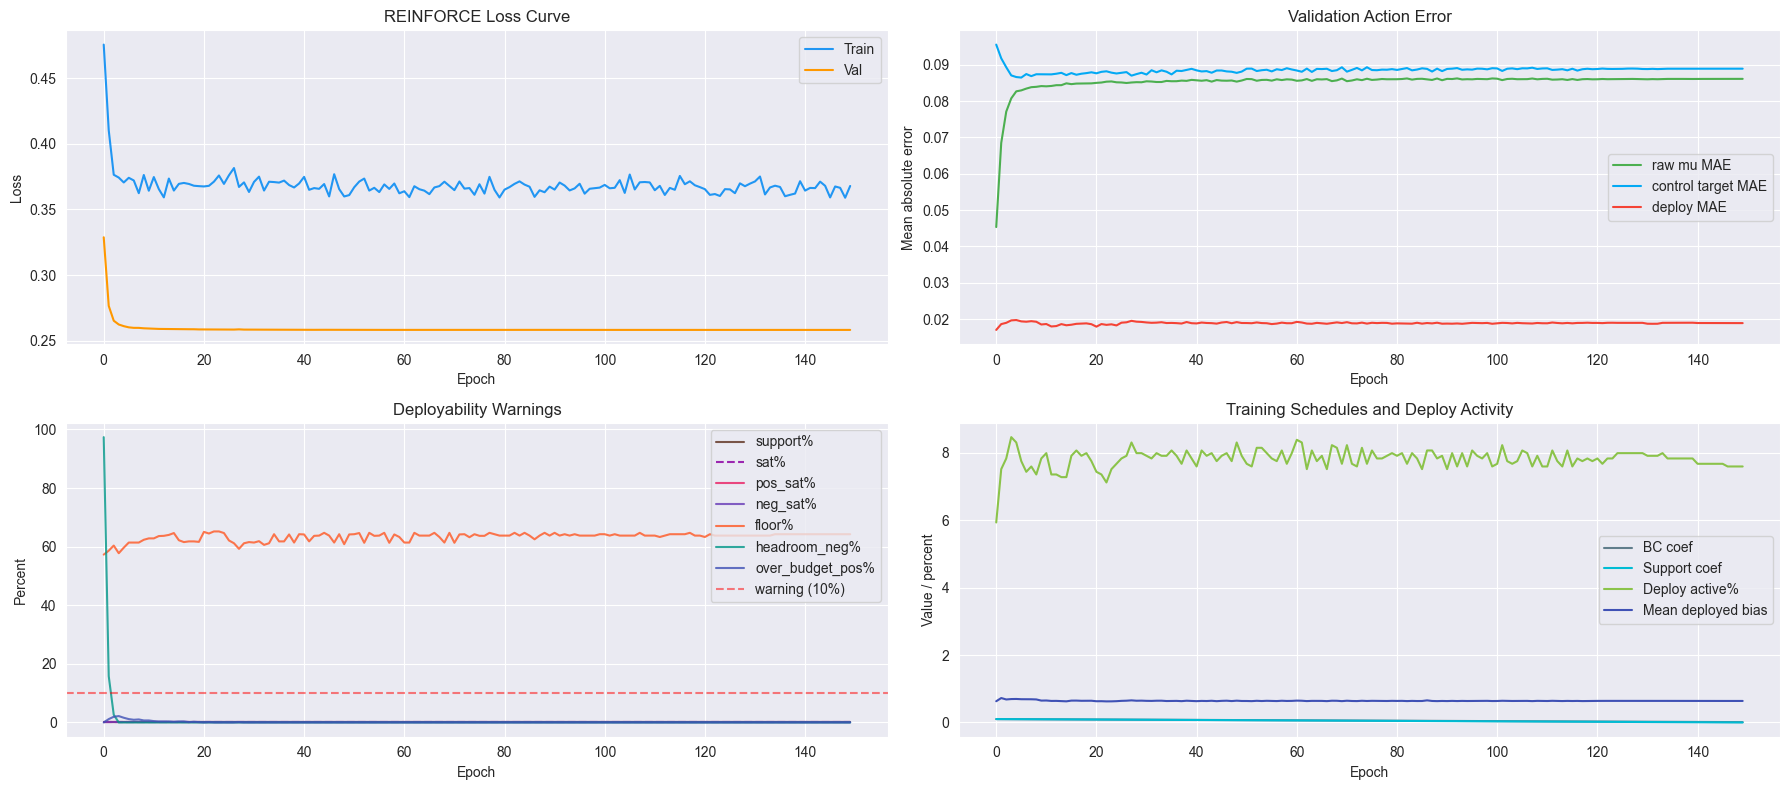

In [14]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s'
)

bp = study.best_params
logging.info(f'Best params loaded: {bp}')

model = PolicyMLP(
    FEATURE_COUNT,
    h1=bp['h1'],
    h2=bp['h2'],
    h3=bp['h3'],
    dropout=bp['dropout']
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=bp['lr'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)

EPOCHS = 150
history = {
    'train': [],
    'val': [],
    'mae': [],
    'control_mae': [],
    'deploy_mae': [],
    'support_pct': [],
    'sat_pct': [],
    'pos_sat_pct': [],
    'neg_sat_pct': [],
    'deploy_active_pct': [],
    'mean_deployed_bias': [],
    'floor_pct': [],
    'mean_mu': [],
    'neg_mu_pct': [],
    'pos_mu_pct': [],
    'headroom_neg_pct': [],
    'near_target_neg_pct': [],
    'over_budget_pos_pct': [],
    'r_budget_mean': [],
    'r_quality_mean': [],
    'r_recovery_mean': [],
    'r_floor_penalty_mean': [],
    'r_target_zone_mean': [],
    'bc_coef': [],
    'support_coef': [],
}
n = len(X_tr_t)

logging.info(f'TRAINING START | epochs={EPOCHS} lr={bp["lr"]:.5g} | fixed-sigma mu policy')

# Initialize adaptive tuner for coefficient adjustment

for epoch in range(EPOCHS):

    progress = epoch / max(EPOCHS - 1, 1)
    bc_coef = linear_schedule(BC_COEF_START, BC_COEF_END, progress)
    support_coef = linear_schedule(SUPPORT_COEF_START, SUPPORT_COEF_END, progress)

    model.train()
    idx = torch.randperm(n)
    t_losses = []

    for start in range(0, n, BATCH_SIZE):
        b = idx[start:start + BATCH_SIZE]
        optimizer.zero_grad()
        loss = reinforce_loss(model, X_tr_t[b], A_tr_t[b], G_tr_t[b], bc_coef=bc_coef, support_coef=support_coef, progress=progress)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        t_losses.append(loss.item())

    scheduler.step()

    metrics = eval_metrics(
        model,
        X_val_t,
        A_val_t,
        G_val_t,
        df_val,
    )
    v_loss, mae, support_viol_pct, sat_pct, pos_sat_pct, neg_sat_pct, zero_pct, deploy_mae, deploy_active_pct, mean_deployed_bias, floor_pct, control_mae, mean_mu, neg_mu_pct, pos_mu_pct, headroom_neg_pct, near_target_neg_pct, over_budget_pos_pct, r_budget_mean, r_quality_mean, r_recovery_mean, r_floor_penalty_mean, r_target_zone_mean = metrics

    train_loss = float(np.mean(t_losses))
    history['train'].append(train_loss)
    history['val'].append(v_loss)
    history['mae'].append(mae)
    history['control_mae'].append(control_mae)
    history['deploy_mae'].append(deploy_mae)
    history['support_pct'].append(support_viol_pct)
    history['sat_pct'].append(sat_pct)
    history['pos_sat_pct'].append(pos_sat_pct)
    history['neg_sat_pct'].append(neg_sat_pct)
    history['deploy_active_pct'].append(deploy_active_pct)
    history['mean_deployed_bias'].append(mean_deployed_bias)
    history['floor_pct'].append(floor_pct)
    history['mean_mu'].append(mean_mu)
    history['neg_mu_pct'].append(neg_mu_pct)
    history['pos_mu_pct'].append(pos_mu_pct)
    history['headroom_neg_pct'].append(headroom_neg_pct)
    history['near_target_neg_pct'].append(near_target_neg_pct)
    history['over_budget_pos_pct'].append(over_budget_pos_pct)
    history['r_budget_mean'].append(r_budget_mean)
    history['r_quality_mean'].append(r_quality_mean)
    history['r_recovery_mean'].append(r_recovery_mean)
    history['r_floor_penalty_mean'].append(r_floor_penalty_mean)
    history['r_target_zone_mean'].append(r_target_zone_mean)
    history['bc_coef'].append(bc_coef)
    history['support_coef'].append(support_coef)

    logging.info(
        f'Epoch {epoch + 1}/{EPOCHS} | train={train_loss:.6f} | val={v_loss:.6f} | '
        f'mae={mae:.6f} | control_mae={control_mae:.6f} | deploy_mae={deploy_mae:.6f} | support%={support_viol_pct:.2f} | '
        f'sat%={sat_pct:.2f} | pos_sat%={pos_sat_pct:.2f} | neg_sat%={neg_sat_pct:.2f} | '
        f'zero%={zero_pct:.2f} | deploy_active%={deploy_active_pct:.2f} | '
        f'mean_bias={mean_deployed_bias:.3f} | floor%={floor_pct:.2f} | '
        f'mean_mu={mean_mu:.4f} | neg_mu%={neg_mu_pct:.2f} | pos_mu%={pos_mu_pct:.2f} | '
        f'headroom_neg%={headroom_neg_pct:.2f} | near_target_neg%={near_target_neg_pct:.2f} | '
        f'over_budget_pos%={over_budget_pos_pct:.2f} | '
        f'r_budget={r_budget_mean:.4f} | r_quality={r_quality_mean:.4f} | '
        f'r_recovery={r_recovery_mean:.4f} | r_floor_pen={r_floor_penalty_mean:.4f} | r_tz={r_target_zone_mean:.4f} | '
        f'bc={bc_coef:.3f} | support={support_coef:.3f}'
    )

    if epoch >= 10 and pos_sat_pct > 10.0:
        logging.warning(
            f'Epoch {epoch + 1}: pos_sat%={pos_sat_pct:.1f} > 10% - '
            'positive collapse detected; inspect diagnostics before export.'
        )

    if epoch >= 10 and neg_sat_pct > 35.0:
        logging.warning(
            f'Epoch {epoch + 1}: neg_sat%={neg_sat_pct:.1f} > 35% - '
            'policy is collapsing toward lower bias instead of tracking headroom.'
        )

    if epoch >= 10 and floor_pct > 50.0:
        logging.warning(
            f'Epoch {epoch + 1}: floor%={floor_pct:.1f} > 50% - '
            'deployed bias spends too much time near the minimum quality floor.'
        )

    if epoch >= 10 and over_budget_pos_pct > 35.0:
        logging.warning(
            f'Epoch {epoch + 1}: over_budget_pos%={over_budget_pos_pct:.1f} > 35% - '
            'policy is still trying to raise quality when GPU is already over budget.'
        )

    if epoch >= 10 and headroom_neg_pct > 35.0:
        logging.warning(
            f'Epoch {epoch + 1}: headroom_neg%={headroom_neg_pct:.1f} > 35% - '
            'policy is still trying to lower quality while comfortably under budget.'
        )

    if epoch >= 20 and deploy_mae > 0.08:
        logging.warning(
            f'Epoch {epoch + 1}: deploy_MAE={deploy_mae:.4f} > 0.08 - '
            'runtime guardrail mismatch still too high.'
        )

fig, axes = plt.subplots(2, 2, figsize=(18, 8))

ax = axes[0, 0]
ax.plot(history['train'], label='Train', color='#2196F3')
ax.plot(history['val'], label='Val', color='#FF9800')
ax.set_title('REINFORCE Loss Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()

ax = axes[0, 1]
ax.plot(history['mae'], color='#4CAF50', label='raw mu MAE')
ax.plot(history['control_mae'], color='#03A9F4', label='control target MAE')
ax.plot(history['deploy_mae'], color='#F44336', label='deploy MAE')
ax.set_title('Validation Action Error')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean absolute error')
ax.legend()

ax = axes[1, 0]
ax.plot(history['support_pct'], color='#795548', label='support%')
ax.plot(history['sat_pct'], color='#9C27B0', linestyle='--', label='sat%')
ax.plot(history['pos_sat_pct'], color='#E91E63', alpha=0.8, label='pos_sat%')
ax.plot(history['neg_sat_pct'], color='#673AB7', alpha=0.8, label='neg_sat%')
ax.plot(history['floor_pct'], color='#FF5722', alpha=0.8, label='floor%')
ax.plot(history['headroom_neg_pct'], color='#009688', alpha=0.8, label='headroom_neg%')
ax.plot(history['over_budget_pos_pct'], color='#3F51B5', alpha=0.8, label='over_budget_pos%')
ax.axhline(10.0, color='red', linestyle='--', alpha=0.5, label='warning (10%)')
ax.set_title('Deployability Warnings')
ax.set_xlabel('Epoch')
ax.set_ylabel('Percent')
ax.legend()

ax = axes[1, 1]
ax.plot(history['bc_coef'], color='#607D8B', label='BC coef')
ax.plot(history['support_coef'], color='#00BCD4', label='Support coef')
ax.plot(history['deploy_active_pct'], color='#8BC34A', label='Deploy active%')
ax.plot(history['mean_deployed_bias'], color='#3F51B5', label='Mean deployed bias')
ax.set_title('Training Schedules and Deploy Activity')
ax.set_xlabel('Epoch')
ax.set_ylabel('Value / percent')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'loss_curve.png', dpi=150)
plt.show()

final_support = history['support_pct'][-1]
final_sat = history['sat_pct'][-1]
final_pos_sat = history['pos_sat_pct'][-1]
final_neg_sat = history['neg_sat_pct'][-1]
final_deploy_mae = history['deploy_mae'][-1]
final_floor_pct = history['floor_pct'][-1]
final_mean_bias = history['mean_deployed_bias'][-1]
final_control_mae = history['control_mae'][-1]
final_mean_mu = history['mean_mu'][-1]
final_neg_mu_pct = history['neg_mu_pct'][-1]
final_headroom_neg_pct = history['headroom_neg_pct'][-1]
final_near_target_neg_pct = history['near_target_neg_pct'][-1]
final_over_budget_pos_pct = history['over_budget_pos_pct'][-1]
final_r_budget_mean = history['r_budget_mean'][-1]
final_r_quality_mean = history['r_quality_mean'][-1]
final_r_recovery_mean = history['r_recovery_mean'][-1]
final_r_floor_penalty_mean = history['r_floor_penalty_mean'][-1]


## 8. Policy Diagnostics
These diagnostics are aligned to the actual Stage 4 bootstrap regime:
- rollout actions are quantized by `RLPolicyController` (`-0.05`, `0.0`, `+0.05` in the current data)
- Unity deploys only `mu`
- the key health checks are action-fit, avoidance of one-sided `-0.20` collapse, and avoidance of living at the bias floor

[2026-04-07 00:13:23,786] INFO - Model device: cuda:0
[2026-04-07 00:13:23,787] INFO - Input device: cuda:0
[2026-04-07 00:13:23,997] INFO - Fixed training sigma: 0.100000
[2026-04-07 00:13:23,998] INFO - Deployable action envelope: +/-0.300
[2026-04-07 00:13:24,000] INFO - Predicted mu stats | mean=-0.031401 | std=0.080176 | min=-0.090000 | max=0.090000
[2026-04-07 00:13:24,002] INFO - Action fit | raw_MAE=0.081485 | deploy_MAE=0.018863 | support%=0.00 | sat%=0.00 | pos_sat%=0.00 | neg_sat%=0.00 | zero%=0.60 | deploy_active%=8.92 | mean_bias=0.919 | floor%=46.07


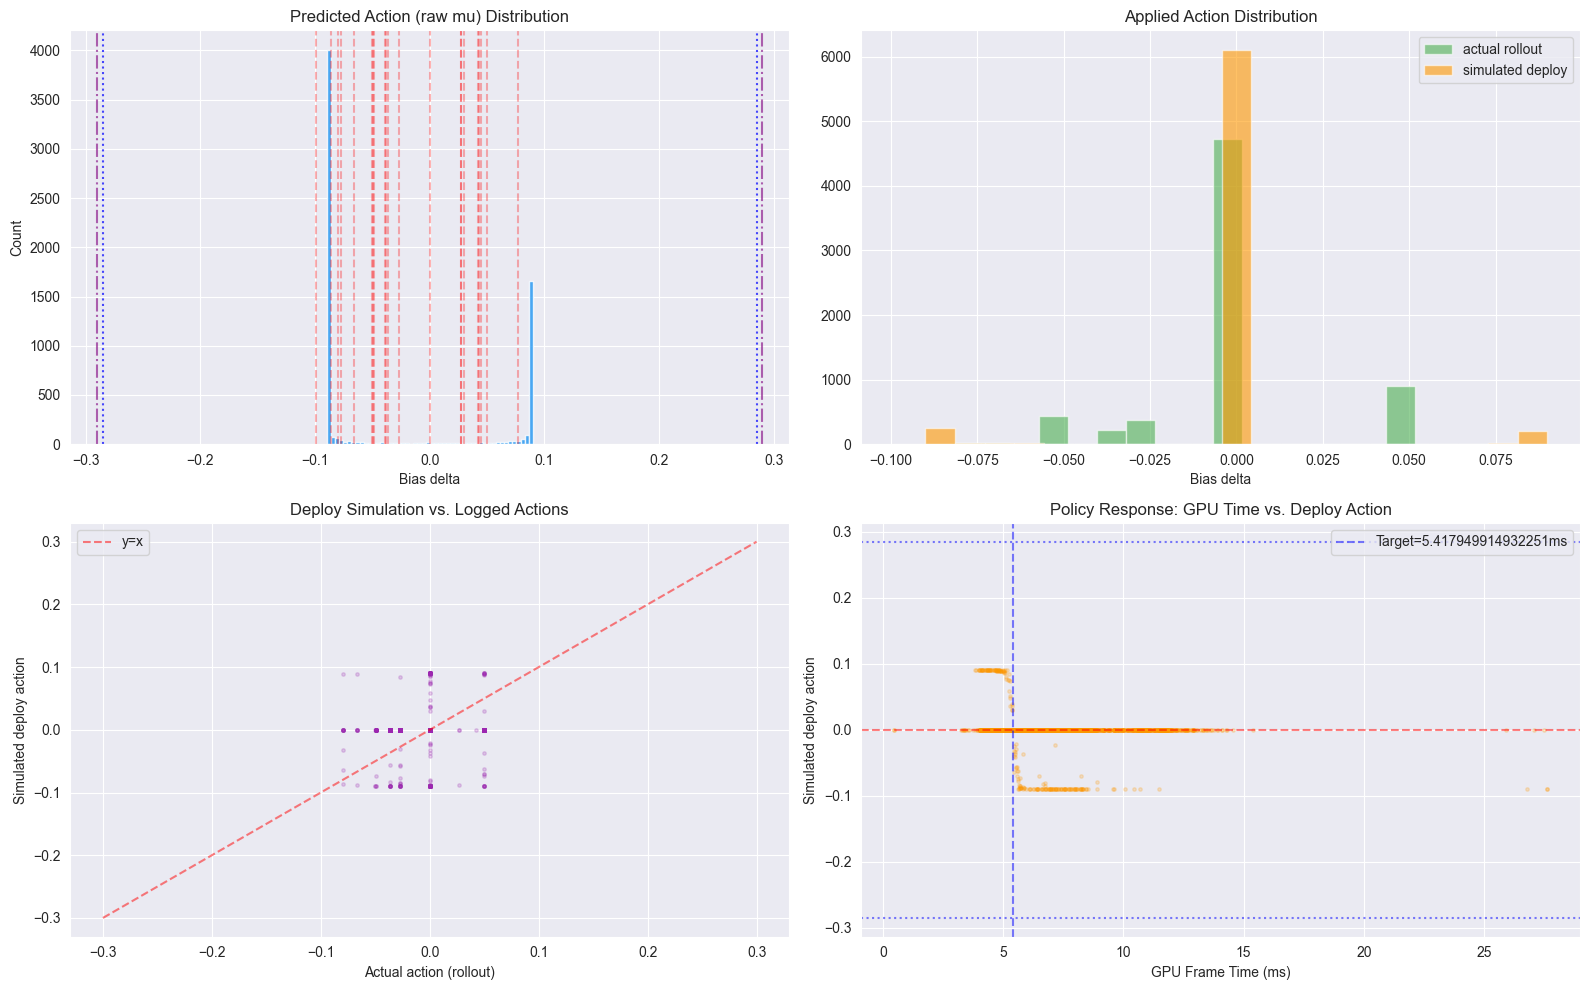

[2026-04-07 00:13:27,136] INFO - Saved: action_diagnostics.png


In [15]:
import logging
import torch
import numpy as np
import matplotlib.pyplot as plt

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s'
)

model = model.to(device)
for name, buf in model.named_buffers():
    model._buffers[name] = buf.to(device)

X_all_t = torch.tensor(X_scaled, dtype=torch.float32, device=device)

logging.info(f'Model device: {next(model.parameters()).device}')
logging.info(f'Input device: {X_all_t.device}')

model.eval()
with torch.no_grad():
    mu_all = model(X_all_t)[0].cpu().numpy().flatten()

deployment_frame = build_deployment_frame(model, df_clean)
raw_mu_all = deployment_frame['raw_mu'].values.astype('float32')
applied_mu_all = deployment_frame['applied_mu'].values.astype('float32')
actual_actions = deployment_frame['action_delta'].values.astype('float32')

mae_all = float(np.mean(np.abs(raw_mu_all - actual_actions)))
deploy_mae_all = float(np.mean(np.abs(applied_mu_all - actual_actions)))
support_viol_pct = float((np.abs(raw_mu_all) > SOFT_SUPPORT_LIMIT).mean() * 100)
sat_pct = float((np.abs(raw_mu_all) >= SAT_WARN_THRESHOLD).mean() * 100)
pos_sat_pct = float((raw_mu_all >= SAT_WARN_THRESHOLD).mean() * 100)
neg_sat_pct = float((raw_mu_all <= -SAT_WARN_THRESHOLD).mean() * 100)
zero_pct = float((np.abs(raw_mu_all) < 0.005).mean() * 100)
deploy_active_pct = float((np.abs(applied_mu_all) > 1e-6).mean() * 100)
mean_deployed_bias = float(np.mean(deployment_frame['deployed_bias'].values.astype('float32')))
floor_pct = float((deployment_frame['deployed_bias'].values.astype('float32') <= (BIAS_MIN + FLOOR_MARGIN)).mean() * 100)

logging.info(f'Fixed training sigma: {TRAIN_SIGMA:.6f}')
logging.info(f'Deployable action envelope: +/-{ACTION_HEAD_SCALE:.3f}')
logging.info(
    f'Predicted mu stats | mean={raw_mu_all.mean():.6f} | std={raw_mu_all.std():.6f} | '
    f'min={raw_mu_all.min():.6f} | max={raw_mu_all.max():.6f}'
)
logging.info(
    f'Action fit | raw_MAE={mae_all:.6f} | deploy_MAE={deploy_mae_all:.6f} | '
    f'support%={support_viol_pct:.2f} | sat%={sat_pct:.2f} | '
    f'pos_sat%={pos_sat_pct:.2f} | neg_sat%={neg_sat_pct:.2f} | '
    f'zero%={zero_pct:.2f} | deploy_active%={deploy_active_pct:.2f} | '
    f'mean_bias={mean_deployed_bias:.3f} | floor%={floor_pct:.2f}'
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.hist(raw_mu_all, bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
for v in sorted(np.unique(actual_actions)):
    ax.axvline(v, color='red', linestyle='--', alpha=0.3)
ax.axvline(SOFT_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.7)
ax.axvline(-SOFT_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.7)
ax.axvline(SAT_WARN_THRESHOLD, color='purple', linestyle='-.', alpha=0.6)
ax.axvline(-SAT_WARN_THRESHOLD, color='purple', linestyle='-.', alpha=0.6)
ax.set_title('Predicted Action (raw mu) Distribution')
ax.set_xlabel('Bias delta')
ax.set_ylabel('Count')

ax = axes[0, 1]
ax.hist(actual_actions, bins=21, color='#4CAF50', alpha=0.6, edgecolor='white', label='actual rollout')
ax.hist(applied_mu_all, bins=21, color='#FF9800', alpha=0.6, edgecolor='white', label='simulated deploy')
ax.set_title('Applied Action Distribution')
ax.set_xlabel('Bias delta')
ax.legend()

ax = axes[1, 0]
ax.scatter(actual_actions[:2000], applied_mu_all[:2000], alpha=0.2, s=6, color='#9C27B0')
ax.plot([-ACTION_HEAD_SCALE, ACTION_HEAD_SCALE], [-ACTION_HEAD_SCALE, ACTION_HEAD_SCALE], 'r--', alpha=0.5, label='y=x')
ax.set_xlabel('Actual action (rollout)')
ax.set_ylabel('Simulated deploy action')
ax.set_title('Deploy Simulation vs. Logged Actions')
ax.legend()

ax = axes[1, 1]
ax.scatter(
    deployment_frame['gpu_frame_time'].values[:3000],
    applied_mu_all[:3000],
    alpha=0.2,
    s=6,
    color='#FF9800'
)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.axhline(SOFT_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.5)
ax.axhline(-SOFT_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.5)
ax.axvline(T_TARGET, color='blue', linestyle='--', alpha=0.5, label=f'Target={T_TARGET}ms')
ax.set_xlabel('GPU Frame Time (ms)')
ax.set_ylabel('Simulated deploy action')
ax.set_title('Policy Response: GPU Time vs. Deploy Action')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'action_diagnostics.png', dpi=150)
plt.show()
logging.info('Saved: action_diagnostics.png')

if pos_sat_pct > 10.0:
    logging.warning('positive mu saturation too high - do not export without reviewing diagnostics')

if neg_sat_pct > 35.0:
    logging.warning('negative mu saturation too high - policy still prefers aggressive quality reduction')

if floor_pct > 50.0:
    logging.warning('deployed bias lives near the minimum floor too often - quality collapse risk remains high')

if deploy_mae_all > 0.08:
    logging.warning('deploy MAE is still high - do not export without reviewing diagnostics')


## 9. ONNX Export
Exports the deployable deterministic mean policy `mu` only. Unity `RLPolicyController` reads `output[0]` as the action delta.

In [16]:
pip install onnxruntime-gpu

Note: you may need to restart the kernel to use updated packages.


In [17]:
import onnxruntime as ort
print(ort.__version__)

1.24.4


In [18]:
# Quality gate before export -- block degenerate feature sets or clearly undeployable policies
nonzero_pct = (df_clean[FEATURE_COLS] != 0).mean() * 100
zero_features = nonzero_pct[nonzero_pct < 1.0].index.tolist()
if zero_features:
    print(f'BLOCKED: {len(zero_features)} features are near-all-zero:')
    for fn in zero_features:
        print(f'  {fn}: {nonzero_pct[fn]:.1f}% non-zero')
    raise RuntimeError('ONNX export blocked -- near-zero feature columns detected.')

if 'deployment_frame' not in globals():
    raise RuntimeError('Run the diagnostics cell before export so deployability checks are available.')

if deploy_mae_all > 0.08:
    raise RuntimeError(
        f'ONNX export blocked -- deploy_MAE={deploy_mae_all:.4f} exceeds the audit safety gate (0.08).'
    )

if pos_sat_pct > 10.0:
    raise RuntimeError(        f'ONNX export blocked -- positive saturation {pos_sat_pct:.2f}% exceeds the audit safety gate (10%).')

if neg_sat_pct > 35.0:
    raise RuntimeError(
        f'ONNX export blocked -- negative saturation {neg_sat_pct:.2f}% indicates the policy is still collapsing toward aggressive quality reduction.'
    )

if floor_pct > 50.0:
    raise RuntimeError(
        f'ONNX export blocked -- floor occupancy {floor_pct:.2f}% indicates the deployed policy still lives too close to the minimum bias.'
    )

if over_budget_pos_pct > 35.0:
    raise RuntimeError(
        f'ONNX export blocked -- over_budget_pos%={over_budget_pos_pct:.2f} means the policy still raises quality while GPU is already over budget.'
    )

if headroom_neg_pct > 35.0:
    raise RuntimeError(
        f'ONNX export blocked -- headroom_neg%={headroom_neg_pct:.2f} means the policy still lowers quality while comfortably under budget.'
    )

print('Quality gate passed. Proceeding with ONNX export.')


Quality gate passed. Proceeding with ONNX export.


In [19]:
onnx_path = MODEL_DIR / 'rl_policy_stage4.onnx'
export_model = model.cpu().eval()
dummy_input  = torch.zeros(1, FEATURE_COUNT, dtype=torch.float32)

torch.onnx.export(
    export_model,
    dummy_input,
    str(onnx_path),
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=12
)
print(f'ONNX exported â†’ {onnx_path}')

import onnxruntime as ort
sess = ort.InferenceSession(str(onnx_path))
out  = sess.run(None, {'input': dummy_input.numpy()})[0]
print(f'ONNX output shape: {out.shape} | value: {out[0,0]:.6f}')
assert out.shape == (1, 1), f'Expected (1,1), got {out.shape}'
print('ONNX validation OK.')
print()
print(f'Next step: assign {onnx_path.name} to RLPolicyController.OnnxAsset in Unity.')


ONNX exported â†’ C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_policy_stage4.onnx


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

## 10. Output Summary

In [ ]:
# === MODEL VIABILITY GATES ===
# Fail fast if training produced an unusable model

final_deploy_active = history['deploy_active_pct'][-1]
final_mean_mu = history['mean_mu'][-1]
final_return = history['episode_return'][-1] if 'episode_return' in history else None

gates_passed = True

# Gate 1: Active action rate
if final_deploy_active < 5.0:
    print(f'❌ GATE FAILED: Policy active only {final_deploy_active:.2f}% (threshold: 5.0%)')
    print('   → Model will mostly hold at runtime. Increase PG_COEF or reduce control coefs.')
    gates_passed = False
else:
    print(f'✅ GATE PASSED: Policy active {final_deploy_active:.2f}%')

# Gate 2: Action balance
neg_mu_pct = history['neg_mu_pct'][-1]
if neg_mu_pct > 70 or neg_mu_pct < 30:
    print(f'❌ GATE FAILED: Action imbalance {neg_mu_pct:.1f}% negative (should be 40-60%)')
    gates_passed = False
else:
    print(f'✅ GATE PASSED: Action balance {neg_mu_pct:.1f}% negative')

# Gate 3: Near-target behavior
near_target_neg = history['near_target_neg_pct'][-1]
if near_target_neg > 70:
    print(f'❌ GATE FAILED: Near-target negative {near_target_neg:.1f}% (too many downward near-target)')
    gates_passed = False
else:
    print(f'✅ GATE PASSED: Near-target behavior {near_target_neg:.1f}%')

if not gates_passed:
    raise RuntimeError('❌ MODEL FAILED VIABILITY GATES. Do not export. Adjust hyperparameters and retrain.')

print('✅ ALL GATES PASSED. Model is viable for deployment.')


In [ ]:
print('Training complete.')
print(f'  Final val loss      : {history["val"][-1]:.4f}')
print(f'  Final val MAE       : {history["mae"][-1]:.4f}')
print(f'  Final deploy MAE    : {history["deploy_mae"][-1]:.4f}')
print(f'  Final support rate  : {history["support_pct"][-1]:.2f}%')
print(f'  Final sat rate      : {history["sat_pct"][-1]:.2f}%')
print(f'  Final deploy active : {history["deploy_active_pct"][-1]:.2f}%')
print(f'  Action head scale   : +/-{ACTION_HEAD_SCALE:.2f}')
print(f'  Training sigma      : fixed {TRAIN_SIGMA:.3f}')
